✅ Font set to: Ayuthaya
Data Loaded: (100, 31)
Generating Pair Plot...


/opt/anaconda3/envs/flood_env/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Ayuthaya.
  self._figure.tight_layout(*args, **kwargs)
/opt/anaconda3/envs/flood_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Ayuthaya.
  fig.canvas.print_figure(bytes_io, **kw)


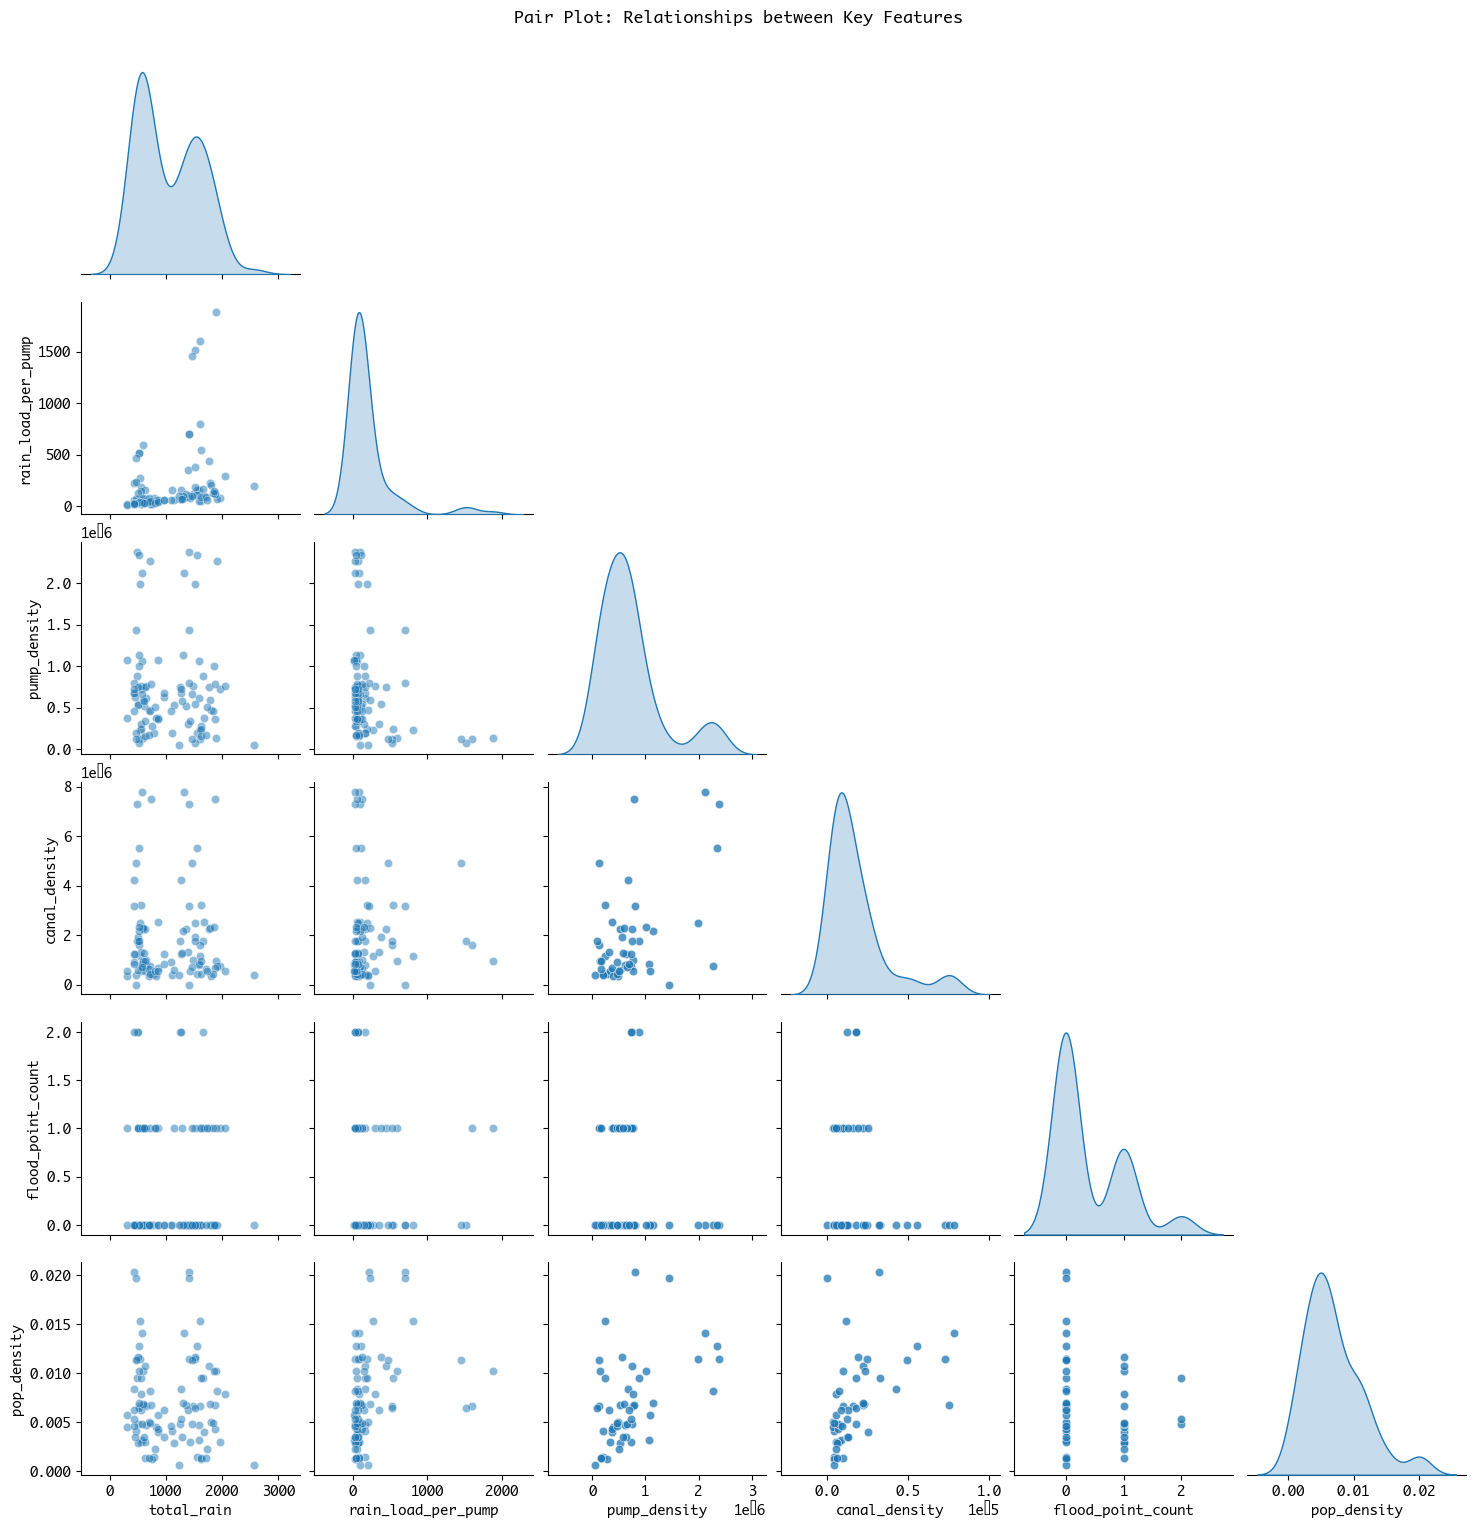

/opt/anaconda3/envs/flood_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Ayuthaya.
  fig.canvas.print_figure(bytes_io, **kw)


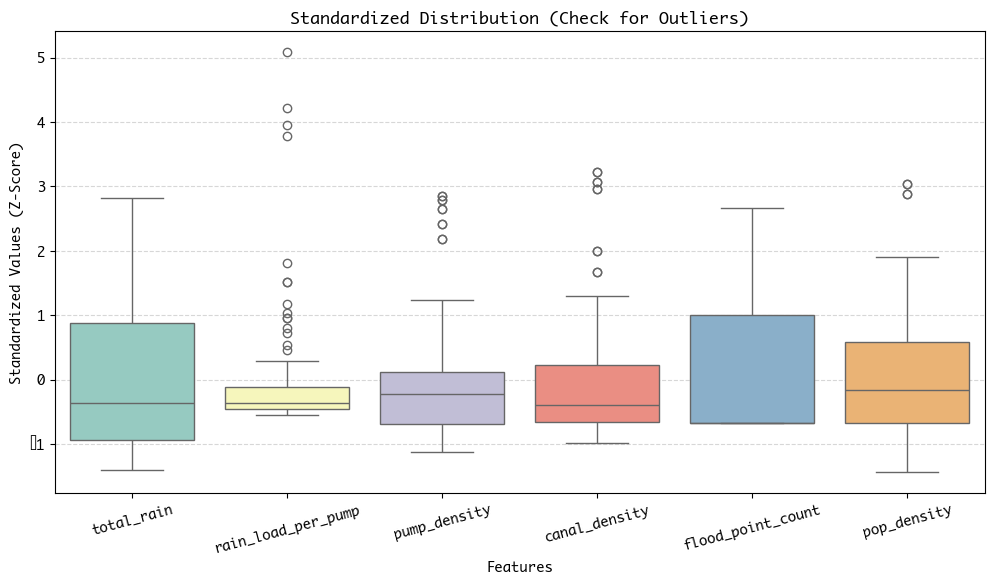

/opt/anaconda3/envs/flood_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Ayuthaya.
  fig.canvas.print_figure(bytes_io, **kw)


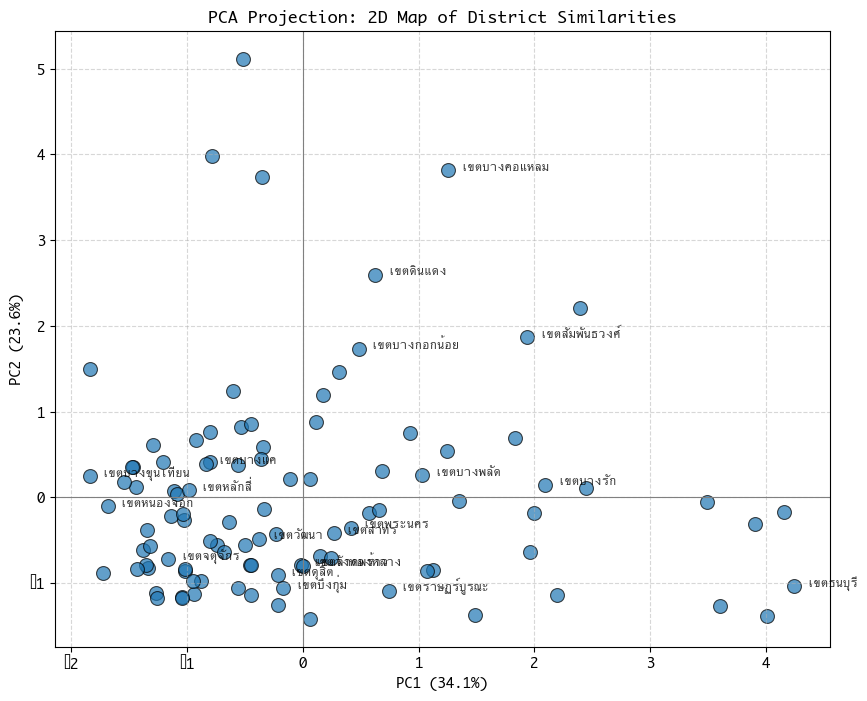

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import platform
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ==========================================
# 0. Config & Font (ตั้งค่าฟอนต์ไทยอีกรอบเผื่อหลุด)
# ==========================================
def set_thai_font():
    system = platform.system()
    if system == 'Windows':
        font_names = ['Tahoma', 'Leelawadee UI', 'Angsana New', 'Microsoft Sans Serif']
    elif system == 'Darwin': # MacOS
        font_names = ['Ayuthaya', 'Thonburi', 'Sukhumvit Set']
    else: # Linux
        font_names = ['Waree', 'Loma', 'Noto Sans Thai', 'Tlwg Typist']

    available_fonts = set(f.name for f in fm.fontManager.ttflist)
    selected_font = None
    for font in font_names:
        if font in available_fonts:
            selected_font = font
            break
            
    if selected_font:
        plt.rcParams['font.family'] = selected_font
        print(f"✅ Font set to: {selected_font}")
    else:
        plt.rcParams['font.family'] = 'Tahoma' # Fallback

set_thai_font()

# ==========================================
# 1. Load Data (โหลดใหม่เพื่อให้แน่ใจว่ามีตัวแปร df_eng)
# ==========================================
engineered_path = '../data/PROCESSED/district_features_engineered.csv'
try:
    df_eng = pd.read_csv(engineered_path)
    print(f"Data Loaded: {df_eng.shape}")
except FileNotFoundError:
    print(f"❌ File not found: {engineered_path}. Please check path.")

# ==========================================
# 2. Advanced Plots (Pair Plot, Box Plot, PCA)
# ==========================================

if 'df_eng' in locals():
    # เลือก Feature ที่เราสนใจจะดูการเกาะกลุ่ม
    cols_to_analyze = [
        'total_rain', 
        'rain_load_per_pump', 
        'pump_density', 
        'canal_density', 
        'flood_point_count',
        'pop_density'
    ]

    # --- Graph 5: Pair Plot (ดูความสัมพันธ์ทุกคู่) ---
    print("Generating Pair Plot...")
    sns.pairplot(df_eng[cols_to_analyze], diag_kind='kde', corner=True, plot_kws={'alpha': 0.5})
    plt.suptitle('Pair Plot: Relationships between Key Features', y=1.02)
    plt.show()

    # --- Graph 6: Box Plot (เช็ค Outlier) ---
    # Scale ข้อมูลก่อนพล็อต เพื่อให้กราฟไม่เบี้ยว
    scaler = StandardScaler()
    df_scaled_viz = pd.DataFrame(scaler.fit_transform(df_eng[cols_to_analyze]), columns=cols_to_analyze)

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_scaled_viz, palette="Set3")
    plt.title('Standardized Distribution (Check for Outliers)')
    plt.xlabel('Features')
    plt.ylabel('Standardized Values (Z-Score)')
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.xticks(rotation=15)
    plt.show()

    # --- Graph 7: PCA Plot (ดูภาพรวมการเกาะกลุ่ม) ---
    pca = PCA(n_components=2)
    principalComponents = pca.fit_transform(df_scaled_viz)
    pca_df = pd.DataFrame(data=principalComponents, columns=['PC1', 'PC2'])

    plt.figure(figsize=(10, 8))
    sns.scatterplot(data=pca_df, x='PC1', y='PC2', s=100, alpha=0.7, edgecolor='k')

    # ใส่ชื่อเขตลงไปในจุดบางจุด
    for i in range(0, len(df_eng), 5): 
        plt.text(pca_df.loc[i, 'PC1']+0.1, pca_df.loc[i, 'PC2'], df_eng.loc[i, 'dname'], fontsize=9, alpha=0.8)

    plt.title('PCA Projection: 2D Map of District Similarities')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.axhline(0, color='grey', linewidth=0.8)
    plt.axvline(0, color='grey', linewidth=0.8)
    plt.show()

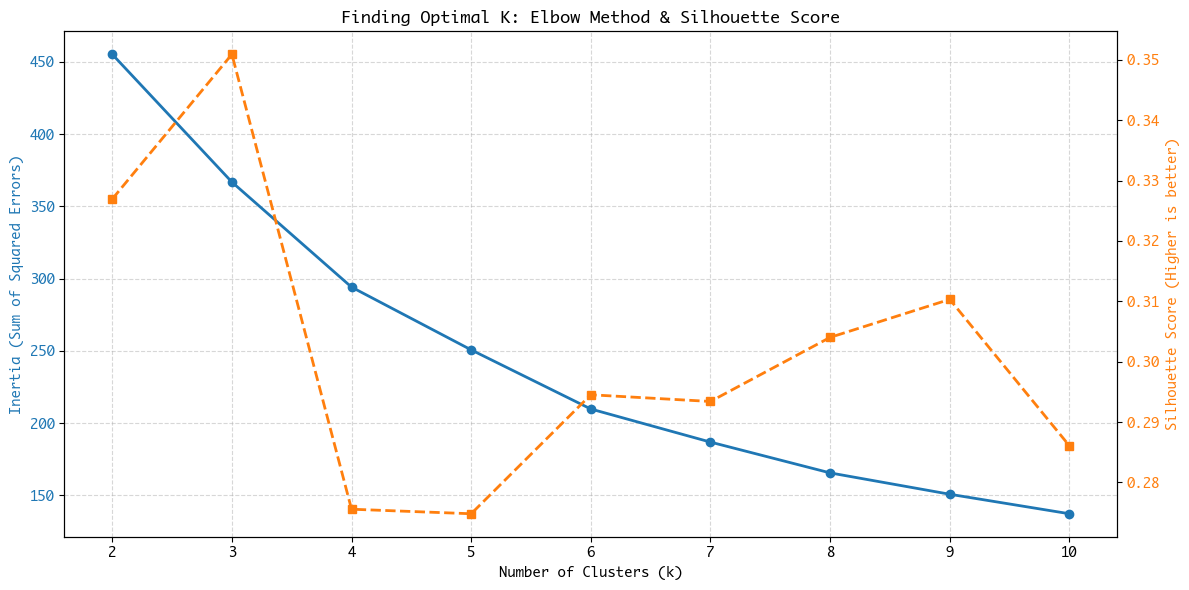

💡 Suggestion based on Silhouette Score: k = 3
💡 Suggestion based on Elbow: Look for the 'knee' point (usually 3 or 4)


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# ==========================================
# 1. Load & Prepare Data
# ==========================================
input_path = '../data/PROCESSED/district_features_engineered.csv'
df = pd.read_csv(input_path)

# เลือก Feature ที่จะใช้ในการจัดกลุ่ม (L2 Features)
# เราเลือกตัวแทนจาก 3 ด้าน: ภัย(Rain), โครงสร้าง(Pump/Canal), พื้นที่(Density)
features_cols = [
    'total_rain',          # ภัยคุกคามหลัก
    'rain_load_per_pump',  # ความสามารถในการรับมือ (สำคัญมาก!)
    'pump_density',        # โครงสร้างพื้นฐาน
    'canal_density',       # ทางระบายน้ำธรรมชาติ
    'pop_density',         # ผลกระทบต่อคน
    'flood_point_count'    # ประวัติเก่า
]

X = df[features_cols]

# Scale ข้อมูล (สำคัญมากสำหรับ K-Means!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 2. Elbow Method & Silhouette Analysis
# ==========================================

inertia = []
sil_scores = []
K_range = range(2, 11) # ลองแบ่งตั้งแต่ 2 ถึง 10 กลุ่ม

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# ==========================================
# 3. Plotting Results
# ==========================================

fig, ax1 = plt.subplots(figsize=(12, 6))

# กราฟ Elbow (Inertia) - ดูจุดหักศอก
color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Sum of Squared Errors)', color=color)
ax1.plot(K_range, inertia, marker='o', color=color, linewidth=2, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

# กราฟ Silhouette Score - ดูความชัดเจนของการแยกกลุ่ม (ยิ่งสูงยิ่งดี)
ax2 = ax1.twinx()  
color = 'tab:orange'
ax2.set_ylabel('Silhouette Score (Higher is better)', color=color)
ax2.plot(K_range, sil_scores, marker='s', linestyle='--', color=color, linewidth=2, label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Finding Optimal K: Elbow Method & Silhouette Score')
fig.tight_layout()
plt.show()

# แนะนำค่า K ที่ดีที่สุดเบื้องต้น
best_k_sil = K_range[np.argmax(sil_scores)]
print(f"💡 Suggestion based on Silhouette Score: k = {best_k_sil}")
print("💡 Suggestion based on Elbow: Look for the 'knee' point (usually 3 or 4)")

🚀 Running K-Means with k=3...

📊 Cluster Profiles (Mean Values):


,total_rain,rain_load_per_pump,pump_density,canal_density,pop_density,flood_point_count,count
cluster,,,,,,,
0,978.605263,116.174058,1.553776e-06,0.000004,0.011503,0.000000,19
1,1560.687500,1150.229167,3.973020e-07,0.000002,0.012481,0.250000,8
2,1018.294521,113.775180,5.236570e-07,0.000001,0.005174,0.520548,73


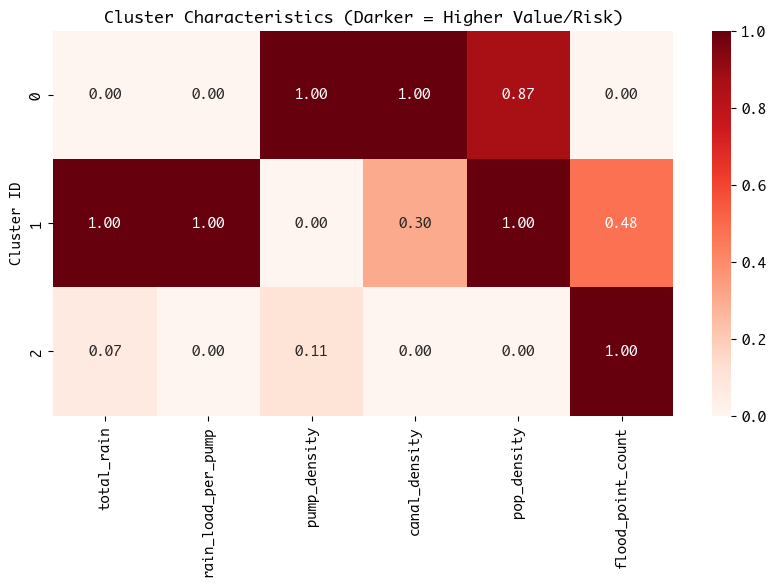

/opt/anaconda3/envs/flood_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Ayuthaya.
  fig.canvas.print_figure(bytes_io, **kw)


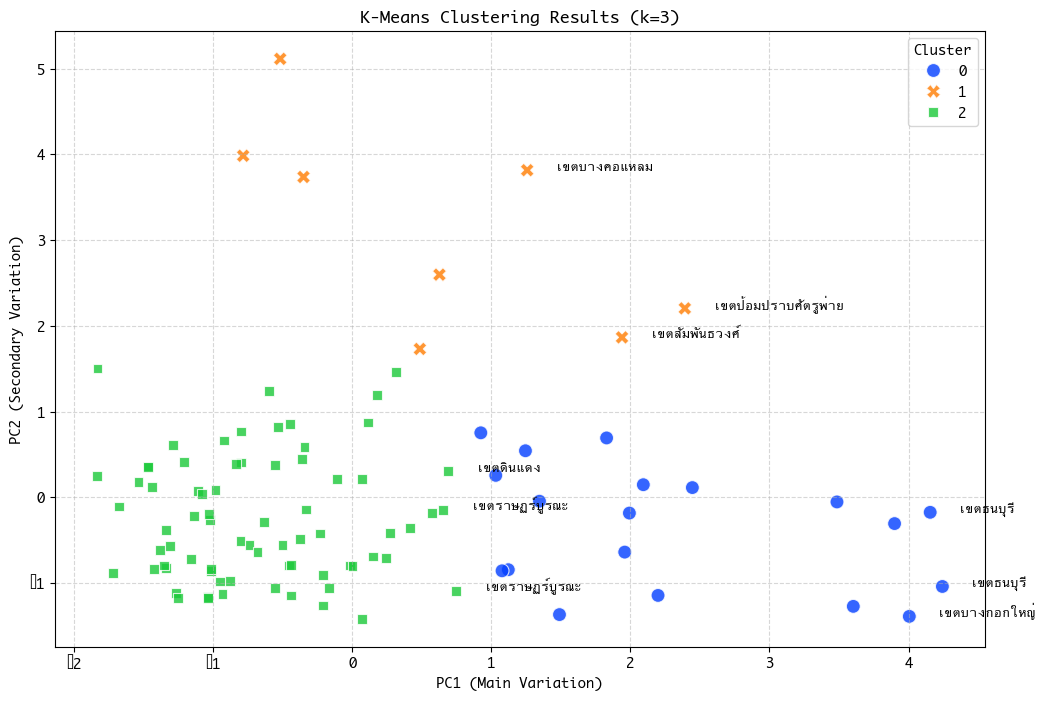

✅ Saved clustered data to ../data/PROCESSED/district_clustered_results.csv


In [4]:
# ==========================================
# 4. Run K-Means (Final Model)
# ==========================================

# เลือก k ที่ต้องการ (แนะนำ 3 หรือ 4)
selected_k = 3 

print(f"🚀 Running K-Means with k={selected_k}...")
kmeans_final = KMeans(n_clusters=selected_k, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_scaled)

# ==========================================
# 5. Cluster Profiling (The Heart of L2 Analysis)
# ==========================================
# ดูค่าเฉลี่ยของแต่ละ Feature ในแต่ละกลุ่ม เพื่อ "ตั้งชื่อ" ให้มัน

# เราจะ Group ตาม Cluster แล้วหาค่าเฉลี่ย
profile = df.groupby('cluster')[features_cols].mean()
profile['count'] = df['cluster'].value_counts() # ดูว่ามีกี่เขตในกลุ่มนั้น

print("\n📊 Cluster Profiles (Mean Values):")
display(profile)

# --- Visualizing Profiles (Heatmap) ---
# ทำ Heatmap เพื่อให้ดูง่ายว่ากลุ่มไหน "แดง" เรื่องอะไร
# เราจะ Normalize ค่าเฉลี่ยให้เป็น 0-1 (MinMax) เพื่อให้เทียบกันง่ายในกราฟเดียว
profile_norm = (profile.drop('count', axis=1) - profile.drop('count', axis=1).min()) / (profile.drop('count', axis=1).max() - profile.drop('count', axis=1).min())

plt.figure(figsize=(10, 5))
sns.heatmap(profile_norm, annot=True, cmap='Reds', fmt=".2f")
plt.title('Cluster Characteristics (Darker = Higher Value/Risk)')
plt.ylabel('Cluster ID')
plt.show()

# ==========================================
# 6. Visualize Clusters on PCA
# ==========================================
# ใช้ PCA ตัวเดิมจากขั้นตอนที่แล้วมาพล็อต แต่คราวนี้ใส่สีตาม Cluster

# คำนวณ PCA อีกรอบ (เผื่อใครไม่ได้รันเซลล์ก่อนหน้า)
pca = PCA(n_components=2)
pc_coords = pca.fit_transform(X_scaled)
df['PC1'] = pc_coords[:, 0]
df['PC2'] = pc_coords[:, 1]

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='PC1', y='PC2', hue='cluster', palette='bright', s=100, alpha=0.8, style='cluster')

# ใส่ชื่อเขตที่เป็น "ตัวตึง" ของแต่ละกลุ่ม (เลือกมาโชว์กลุ่มละ 2-3 เขต)
for cluster_id in range(selected_k):
    # เลือกเขตในกลุ่มนี้มา 3 อันดับแรกที่มีค่า PC1 สูงสุด (พวกที่โดดเด่นสุดในกลุ่ม)
    top_districts = df[df['cluster'] == cluster_id].nlargest(3, 'PC1')
    for i, row in top_districts.iterrows():
        plt.text(row['PC1']+0.2, row['PC2'], row['dname'], fontsize=10, fontweight='bold', color='black')

plt.title(f'K-Means Clustering Results (k={selected_k})')
plt.xlabel('PC1 (Main Variation)')
plt.ylabel('PC2 (Secondary Variation)')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ==========================================
# 7. Save Results
# ==========================================
output_clustered_path = '../data/PROCESSED/district_clustered_results.csv'
df.to_csv(output_clustered_path, index=False)
print(f"✅ Saved clustered data to {output_clustered_path}")


🚀 Testing K-Means with k=2
📊 Cluster Profiles (k=2):


,total_rain,rain_load_per_pump,pump_density,canal_density,pop_density,flood_point_count,count
cluster_k2,,,,,,,
0,1038.954545,230.309414,1.448933e-06,0.000004,0.012272,0.000000,22
1,1058.429487,187.793865,5.006488e-07,0.000001,0.005463,0.512821,78


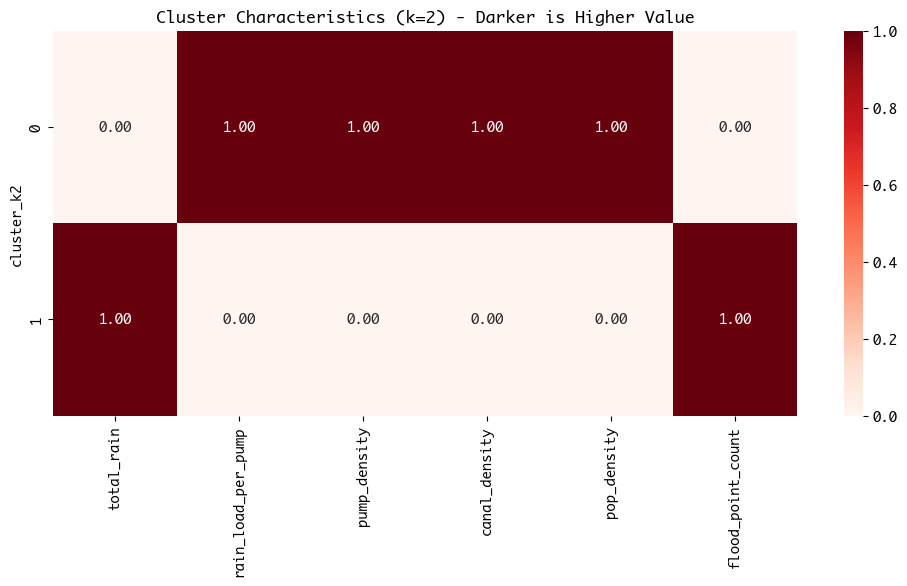

/var/folders/89/hx457xt54dl3cdz1fssyz4tr0000gn/T/ipykernel_75172/2901062781.py:45: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Ayuthaya.
  plt.tight_layout()
/opt/anaconda3/envs/flood_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Ayuthaya.
  fig.canvas.print_figure(bytes_io, **kw)


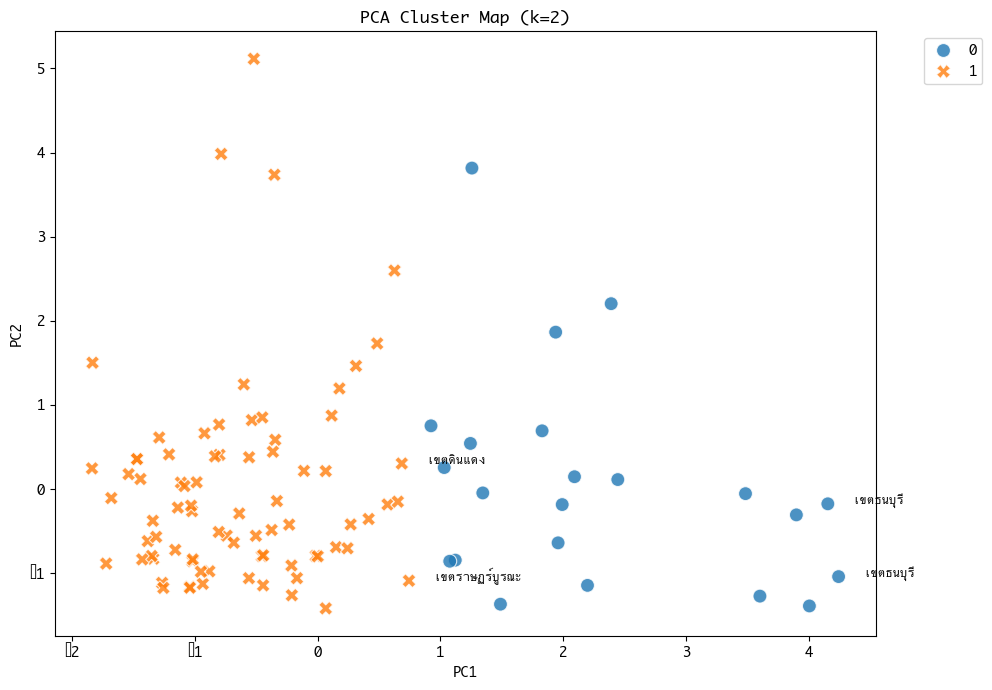


🚀 Testing K-Means with k=3
📊 Cluster Profiles (k=3):


,total_rain,rain_load_per_pump,pump_density,canal_density,pop_density,flood_point_count,count
cluster_k3,,,,,,,
0,978.605263,116.174058,1.553776e-06,0.000004,0.011503,0.000000,19
1,1560.687500,1150.229167,3.973020e-07,0.000002,0.012481,0.250000,8
2,1018.294521,113.775180,5.236570e-07,0.000001,0.005174,0.520548,73


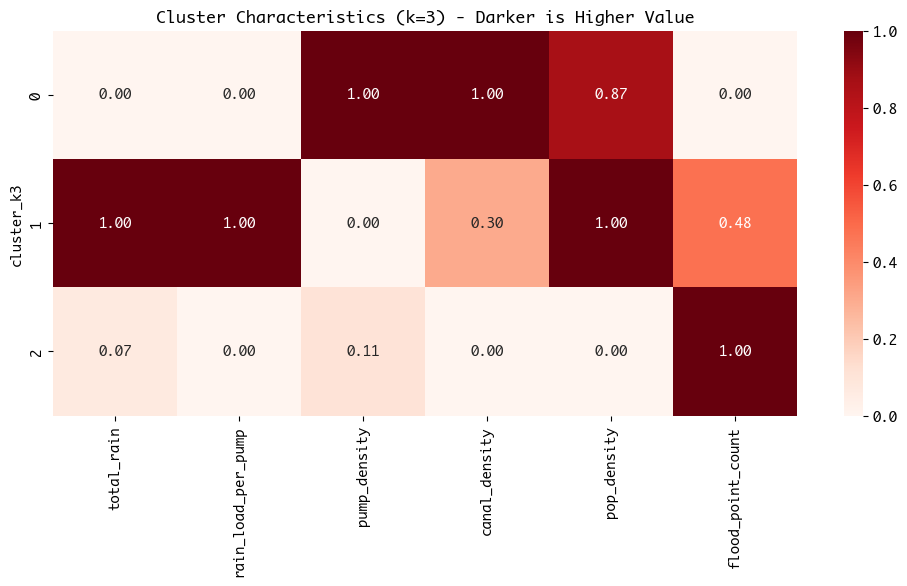

/var/folders/89/hx457xt54dl3cdz1fssyz4tr0000gn/T/ipykernel_75172/2901062781.py:45: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Ayuthaya.
  plt.tight_layout()
/opt/anaconda3/envs/flood_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Ayuthaya.
  fig.canvas.print_figure(bytes_io, **kw)


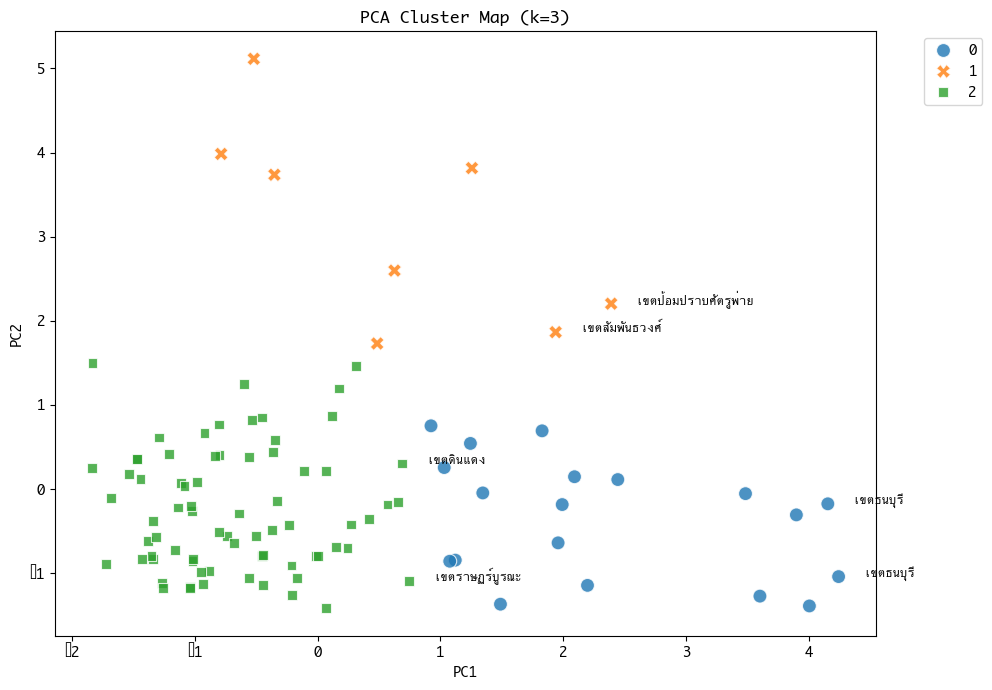


🚀 Testing K-Means with k=4
📊 Cluster Profiles (k=4):


,total_rain,rain_load_per_pump,pump_density,canal_density,pop_density,flood_point_count,count
cluster_k4,,,,,,,
0,1024.734375,124.569806,5.573362e-07,0.000001,0.005624,1.1875,32
1,1014.723404,121.679423,5.133846e-07,0.000001,0.005448,0.0000,47
2,1054.562500,171.972619,1.766424e-06,0.000004,0.013116,0.0000,16
3,1611.600000,1451.600000,1.401046e-07,0.000002,0.010050,0.4000,5


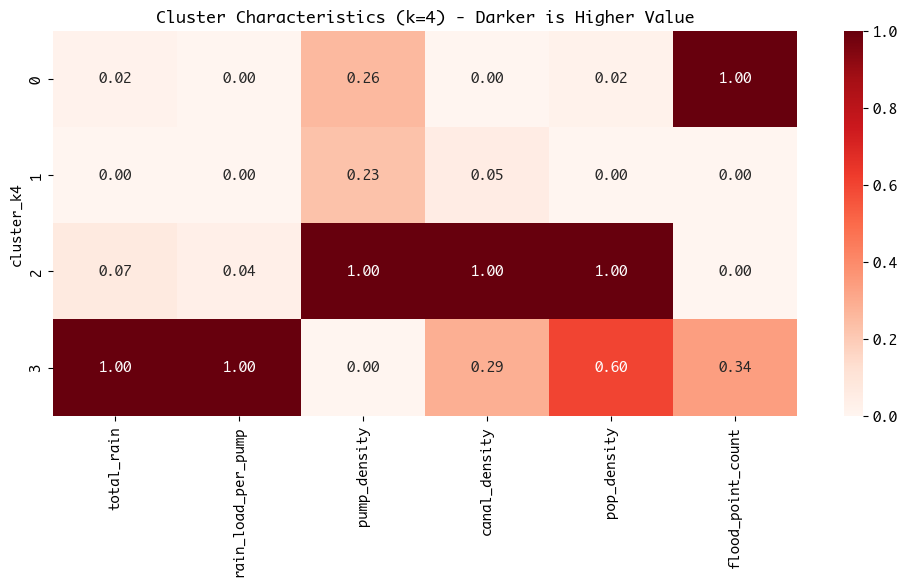

/var/folders/89/hx457xt54dl3cdz1fssyz4tr0000gn/T/ipykernel_75172/2901062781.py:45: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Ayuthaya.
  plt.tight_layout()
/opt/anaconda3/envs/flood_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Ayuthaya.
  fig.canvas.print_figure(bytes_io, **kw)


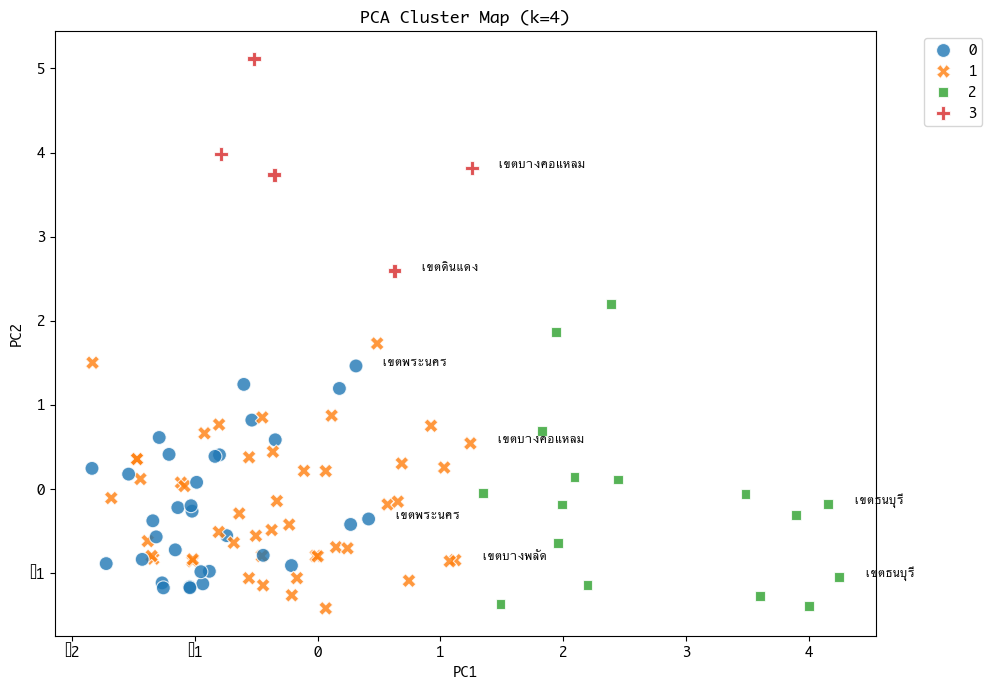


🚀 Testing K-Means with k=5
📊 Cluster Profiles (k=5):


,total_rain,rain_load_per_pump,pump_density,canal_density,pop_density,flood_point_count,count
cluster_k5,,,,,,,
0,1054.550000,81.117857,1.926226e-06,0.000006,0.011333,0.000000,10
1,638.984375,102.271669,6.333158e-07,0.000001,0.006900,0.000000,32
2,747.000000,101.945385,5.604999e-07,0.000001,0.005616,1.260870,23
3,1552.285714,1237.428571,4.192839e-07,0.000002,0.012897,0.285714,7
4,1656.232143,165.146883,5.561528e-07,0.000001,0.005092,0.321429,28


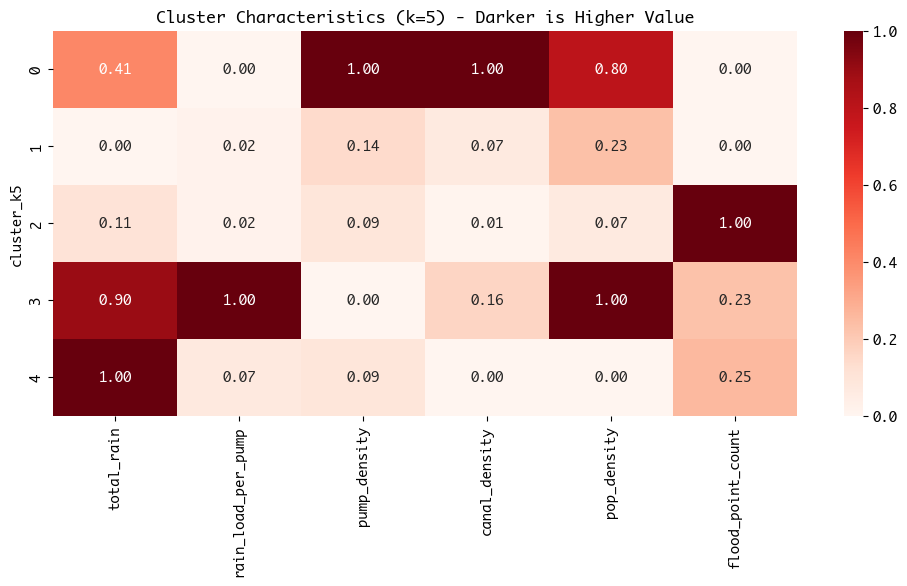

/var/folders/89/hx457xt54dl3cdz1fssyz4tr0000gn/T/ipykernel_75172/2901062781.py:45: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Ayuthaya.
  plt.tight_layout()
/opt/anaconda3/envs/flood_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Ayuthaya.
  fig.canvas.print_figure(bytes_io, **kw)


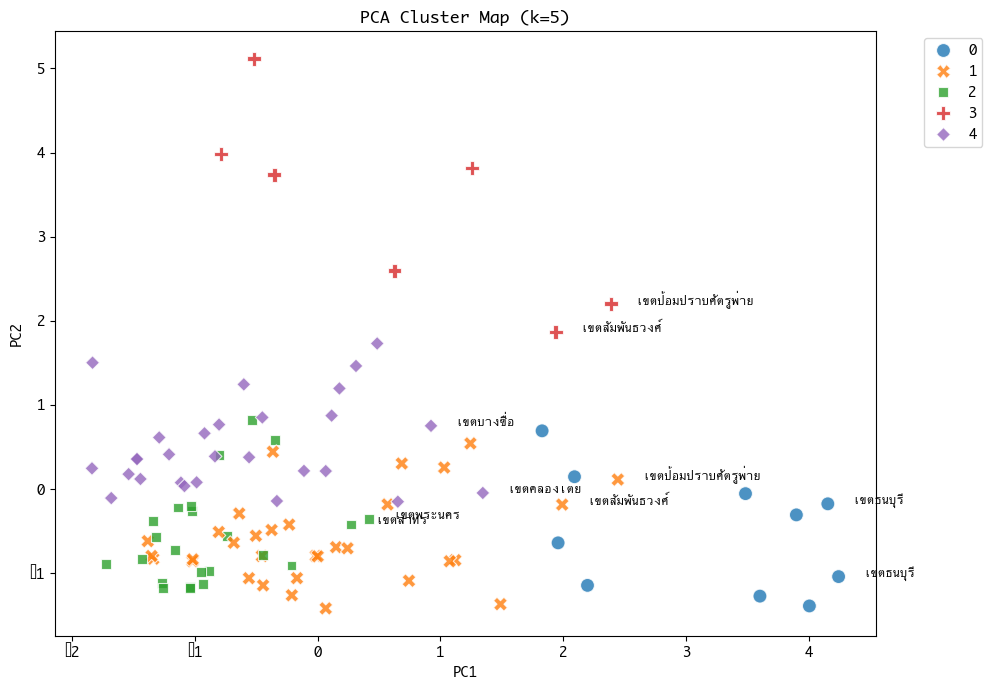


🚀 Testing K-Means with k=6
📊 Cluster Profiles (k=6):


,total_rain,rain_load_per_pump,pump_density,canal_density,pop_density,flood_point_count,count
cluster_k6,,,,,,,
0,1614.500000,1614.500000,1.160702e-07,0.000002,0.008717,0.50000,4
1,690.183333,92.667161,5.619375e-07,0.000001,0.005611,0.00000,30
2,1682.200000,172.376319,4.791187e-07,0.000001,0.004926,0.36000,25
3,974.666667,487.333333,8.235688e-07,0.000001,0.018469,0.00000,6
4,1097.250000,74.880159,1.982821e-06,0.000005,0.010816,0.00000,12
5,747.000000,101.945385,5.604999e-07,0.000001,0.005616,1.26087,23


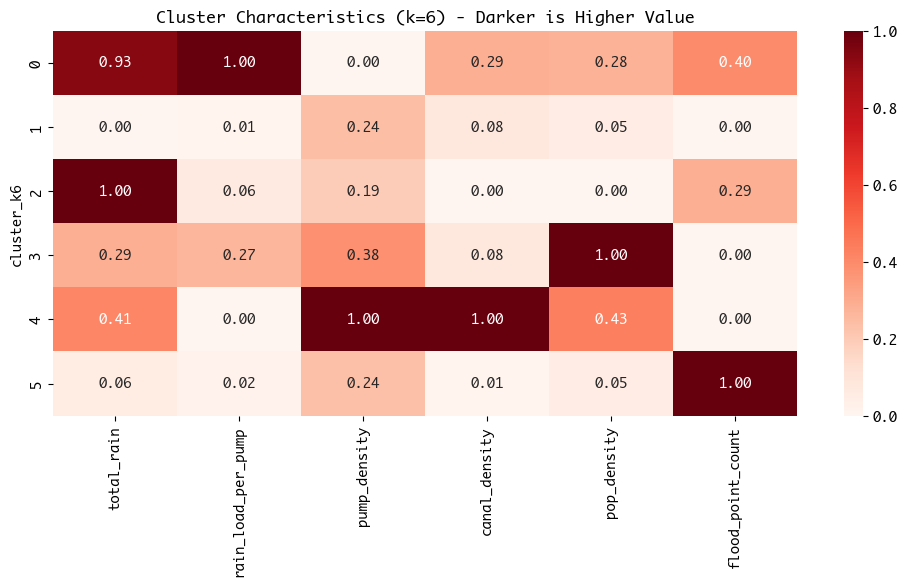

/var/folders/89/hx457xt54dl3cdz1fssyz4tr0000gn/T/ipykernel_75172/2901062781.py:45: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Ayuthaya.
  plt.tight_layout()
/opt/anaconda3/envs/flood_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Ayuthaya.
  fig.canvas.print_figure(bytes_io, **kw)


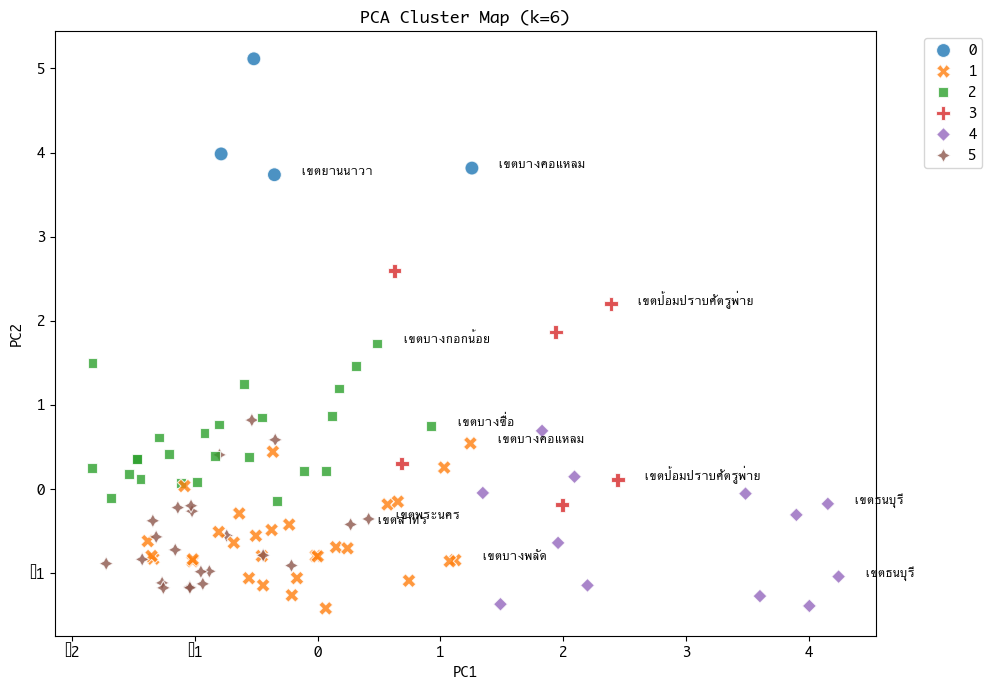

In [6]:
# ==========================================
# 8. Experimenting with k=4 and k=6
# ==========================================

k_experiments = [2,3,4,5,6]

for k in k_experiments:
    print(f"\n{'='*40}")
    print(f"🚀 Testing K-Means with k={k}")
    print(f"{'='*40}")
    
    # 1. Fit Model
    kmeans_exp = KMeans(n_clusters=k, random_state=42, n_init=10)
    df[f'cluster_k{k}'] = kmeans_exp.fit_predict(X_scaled)
    
    # 2. Profiling (ดูหน้าตาของแต่ละกลุ่ม)
    profile = df.groupby(f'cluster_k{k}')[features_cols].mean()
    profile['count'] = df[f'cluster_k{k}'].value_counts()
    
    print(f"📊 Cluster Profiles (k={k}):")
    display(profile)
    
    # 3. Heatmap Visualization
    # Normalize เพื่อให้พล็อตกราฟสวย (0-1)
    cols_to_plot = profile.drop('count', axis=1)
    profile_norm = (cols_to_plot - cols_to_plot.min()) / (cols_to_plot.max() - cols_to_plot.min())
    
    plt.figure(figsize=(12, 5))
    sns.heatmap(profile_norm, annot=True, cmap='Reds', fmt=".2f")
    plt.title(f'Cluster Characteristics (k={k}) - Darker is Higher Value')
    plt.show()
    
    # 4. PCA Visualization
    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=df, x='PC1', y='PC2', hue=f'cluster_k{k}', palette='tab10', s=100, alpha=0.8, style=f'cluster_k{k}')
    
    # ใส่ชื่อเขตตัวท็อปของแต่ละกลุ่ม
    for cluster_id in range(k):
        top_districts = df[df[f'cluster_k{k}'] == cluster_id].nlargest(2, 'PC1') # เอามาโชว์กลุ่มละ 2 ชื่อพอ
        for i, row in top_districts.iterrows():
            plt.text(row['PC1']+0.2, row['PC2'], row['dname'], fontsize=9, color='black', fontweight='bold')
            
    plt.title(f'PCA Cluster Map (k={k})')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# ==========================================
# 9. Save All Experiments
# ==========================================
# บันทึกผลลัพธ์ทั้งหมดลงไฟล์เดียว เพื่อเอาไปเลือกทีหลัง
# df.to_csv('../data/PROCESSED/district_clustered_comparison.csv', index=False)
# print("✅ Saved comparison results to ../data/PROCESSED/district_clustered_comparison.csv")

cluster
0     116.174058
1    1150.229167
2     113.775180
Name: rain_load_per_pump, dtype: float64

✅ Risk Levels Assigned:
risk_level
Well Managed    73
Low Risk        19
High Risk        8
Name: count, dtype: int64

📊 Model Performance:
              precision    recall  f1-score   support

   High Risk       1.00      0.50      0.67         2
    Low Risk       1.00      1.00      1.00         4
Well Managed       0.93      1.00      0.97        14

    accuracy                           0.95        20
   macro avg       0.98      0.83      0.88        20
weighted avg       0.95      0.95      0.94        20



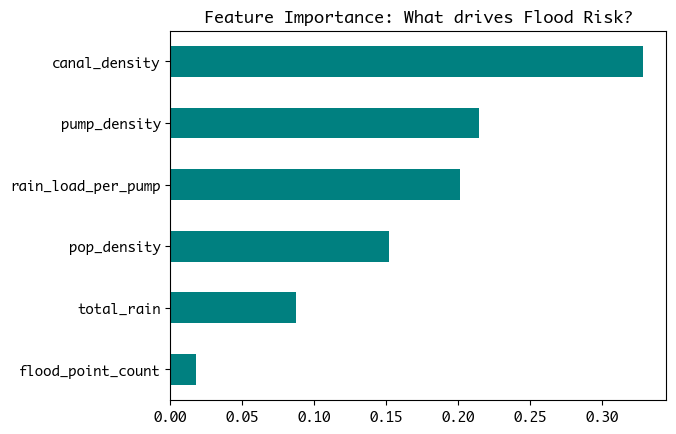

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# 1. Apply Final Clustering (k=3)
# ==========================================
input_path = '../data/PROCESSED/district_features_engineered.csv'
df = pd.read_csv(input_path)

# Features เดิมที่ใช้จัดกลุ่ม
features_cols = ['total_rain', 'rain_load_per_pump', 'pump_density', 
                 'canal_density', 'pop_density', 'flood_point_count']
X = df[features_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# รัน K-Means รอบสุดท้าย
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# ==========================================
# 2. Assign Labels (ตั้งชื่อกลุ่มให้เข้าใจง่าย)
# ==========================================
# *หมายเหตุ: เช็ค Heatmap ของคุณอีกทีนะว่าเลขไหนเป็นกลุ่มไหน 
# (สมมติจากรูป: 1=High Risk, 2=Well Managed, 0=Safe)
# แต่ Python อาจจะสลับเลขได้ ต้องดูค่า Mean ประกอบ

# ดูค่าเฉลี่ยเพื่อ Map ชื่อให้ถูก
print(df.groupby('cluster')['rain_load_per_pump'].mean())

# สมมติว่า:
# กลุ่มที่มี rain_load_per_pump สูงสุด -> High Risk
# กลุ่มที่มี pump_density สูงสุด -> Well Managed
# ที่เหลือ -> Low Risk

# Auto-Labeling Logic (เพื่อให้ชัวร์)
mean_load = df.groupby('cluster')['rain_load_per_pump'].mean()
high_risk_id = mean_load.idxmax() # กลุ่มที่ภาระปั๊มหนักสุด

mean_pump = df.groupby('cluster')['pump_density'].mean()
well_managed_id = mean_pump.idxmax() # กลุ่มที่ปั๊มเยอะสุด (ถ้าไม่ซ้ำกับ High Risk)
if well_managed_id == high_risk_id:
     # ถ้าซ้ำ ให้หาอันรองลงมา หรือดู Logic อื่น (อันนี้เขียนเผื่อไว้)
     pass

# Map ชื่อ (ปรับแก้เลขตามผลรันจริงของคุณได้เลย)
# 0: Low Risk, 1: High Risk, 2: Well Managed
risk_mapping = {
    0: 'Low Risk',      
    1: 'High Risk',     
    2: 'Well Managed'   
}
# **สำคัญ: เช็คผล print ด้านบนก่อน map นะครับ**

df['risk_level'] = df['cluster'].map(risk_mapping)

print("\n✅ Risk Levels Assigned:")
print(df['risk_level'].value_counts())

# ==========================================
# 3. Train Supervised Model (L3) - Random Forest
# ==========================================
# เป้าหมาย: ให้ AI เรียนรู้ว่า "ถ้าฝนเท่านี้ ปั๊มเท่านี้ -> จะเสี่ยงแค่ไหน"
# เพื่อเอาไปทำ L4 (What-if Analysis)

X_model = df[features_cols] # Input features
y_model = df['risk_level']  # Target (สิ่งที่เราเพิ่งสร้าง)

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X_model, y_model, test_size=0.2, random_state=42)

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate
y_pred = rf_model.predict(X_test)
print("\n📊 Model Performance:")
print(classification_report(y_test, y_pred))

# ==========================================
# 4. Feature Importance (L2 Insight)
# ==========================================
# ดูว่าปัจจัยอะไรสำคัญที่สุดในการชี้วัดความเสี่ยง
importances = pd.Series(rf_model.feature_importances_, index=features_cols)
importances.sort_values().plot(kind='barh', color='teal')
plt.title('Feature Importance: What drives Flood Risk?')
plt.show()

# Save Final Labeled Data for L4 Application
# df.to_csv('../data/PROCESSED/district_risk_labeled.csv', index=False)

🎯 Starting L4 Simulation: The 'Rescue Mission'...

🚨 TARGET IDENTIFIED: เขตราชเทวี
   - Current Pumps: 1
   - Total Rain: 1888.50 mm
   - Current Risk: High Risk
----------------------------------------
   ➕ Adding 0 pumps (Total 1) --> Risk: High Risk
   ➕ Adding 1 pumps (Total 2) --> Risk: Well Managed

✅ SOLUTION FOUND! We need to add 1 pumps.
   ➕ Adding 2 pumps (Total 3) --> Risk: Well Managed
   ➕ Adding 3 pumps (Total 4) --> Risk: Well Managed
   ➕ Adding 4 pumps (Total 5) --> Risk: Well Managed
   ➕ Adding 5 pumps (Total 6) --> Risk: Well Managed
   ➕ Adding 6 pumps (Total 7) --> Risk: Well Managed
   ➕ Adding 7 pumps (Total 8) --> Risk: Well Managed
   ➕ Adding 8 pumps (Total 9) --> Risk: Well Managed
   ➕ Adding 9 pumps (Total 10) --> Risk: Low Risk
   ➕ Adding 10 pumps (Total 11) --> Risk: Low Risk
   ➕ Adding 11 pumps (Total 12) --> Risk: Low Risk
   ➕ Adding 12 pumps (Total 13) --> Risk: Low Risk
   ➕ Adding 13 pumps (Total 14) --> Risk: Low Risk
   ➕ Adding 14 pumps (Tota

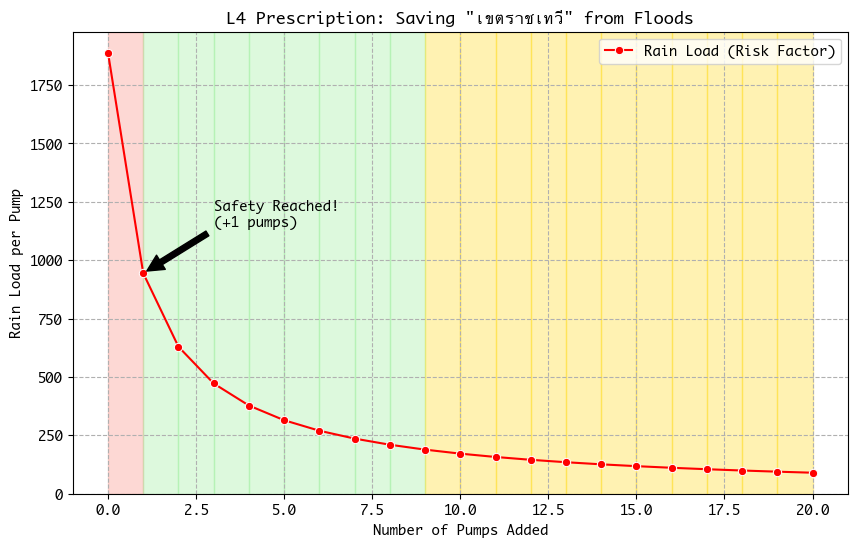


💡 Recommendation (L4 Output):
To move 'เขตราชเทวี' from High Risk to Well Managed,
the recommended action is to install at least 1 additional pumps.


In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# 1. Load Model & Data (ถ้าแยกไฟล์ต้องโหลดใหม่)
# ==========================================
# สมมติว่าตัวแปร rf_model, df, และ features_cols ยังอยู่ใน Memory จากไฟล์ที่แล้ว
# ถ้าไม่มี ให้ย้อนกลับไปรันไฟล์ 03 ก่อน หรือใช้ joblib load โมเดล

print("🎯 Starting L4 Simulation: The 'Rescue Mission'...")

# ==========================================
# 2. Select a 'High Risk' District to Rescue
# ==========================================
# เลือกเขตที่เป็น High Risk มา 1 เขต (เอาตัวที่มี Rain Load สูงสุด)
high_risk_districts = df[df['risk_level'] == 'High Risk']

if high_risk_districts.empty:
    print("🎉 Good news! No High Risk districts found.")
else:
    # เลือกตัวอย่างมา 1 เขต (ตัวที่อาการหนักสุด)
    target_district = high_risk_districts.sort_values(by='rain_load_per_pump', ascending=False).iloc[0]
    
    district_name = target_district['dname']
    current_pumps = target_district['pump_number']
    current_rain = target_district['total_rain']
    current_risk = target_district['risk_level']
    
    print(f"\n🚨 TARGET IDENTIFIED: {district_name}")
    print(f"   - Current Pumps: {current_pumps}")
    print(f"   - Total Rain: {current_rain:.2f} mm")
    print(f"   - Current Risk: {current_risk}")
    print("-" * 40)

    # ==========================================
    # 3. The 'What-if' Simulation Loop
    # ==========================================
    # เราจะลองเพิ่มปั๊มทีละ 1 ตัว -> คำนวณ Rain Load ใหม่ -> ให้ AI ทำนายใหม่
    
    simulation_results = []
    found_solution = False
    
    # ลองเพิ่มปั๊มตั้งแต่ 1 ตัว จนถึง 20 ตัว
    for added_pumps in range(0, 21):
        # 3.1 จำลองสถานการณ์ (Action)
        new_pump_count = current_pumps + added_pumps
        
        # 3.2 คำนวณ Feature ใหม่ (Re-calculate Engineered Features)
        # *สำคัญมาก* โมเดลใช้ 'rain_load' ไม่ใช่ 'pump_number' ตรงๆ เราต้องคำนวณใหม่
        new_rain_load = current_rain / new_pump_count
        new_pump_density = new_pump_count / target_district['AREA']
        
        # สร้างข้อมูลจำลอง (Copy ข้อมูลเดิมมา แล้วแก้เฉพาะค่าที่เปลี่ยน)
        simulated_data = target_district.copy()
        simulated_data['rain_load_per_pump'] = new_rain_load
        simulated_data['pump_density'] = new_pump_density
        # (Feature อื่นๆ เช่น canal, rain, population ถือว่าคงที่)
        
        # 3.3 ให้ AI ทำนาย (Prediction)
        # เตรียม Input ให้ตรงกับตอนเทรน (เรียง column ให้ถูก)
        X_sim = pd.DataFrame([simulated_data[features_cols]]) 
        predicted_risk = rf_model.predict(X_sim)[0]
        
        # เก็บผลลัพธ์
        simulation_results.append({
            'Added Pumps': added_pumps,
            'Total Pumps': new_pump_count,
            'Rain Load': new_rain_load,
            'Predicted Risk': predicted_risk
        })
        
        print(f"   ➕ Adding {added_pumps} pumps (Total {new_pump_count}) --> Risk: {predicted_risk}")
        
        # 3.4 เช็คว่ารอดหรือยัง? (Stop Condition)
        if predicted_risk != 'High Risk' and not found_solution:
            print(f"\n✅ SOLUTION FOUND! We need to add {added_pumps} pumps.")
            found_solution = True
            # เราอาจจะอยาก loop ต่ออีกนิดเพื่อให้เห็นกราฟสวยๆ ว่ามันลดลงไปเรื่อยๆ

    # ==========================================
    # 4. Visualize the Simulation (L4 Dashboard)
    # ==========================================
    sim_df = pd.DataFrame(simulation_results)
    
    plt.figure(figsize=(10, 6))
    
    # วาดเส้น Rain Load ที่ลดลง
    sns.lineplot(data=sim_df, x='Added Pumps', y='Rain Load', marker='o', color='red', label='Rain Load (Risk Factor)')
    
    # ระบายสีพื้นหลังตามระดับความเสี่ยงที่ทำนายได้
    # (อันนี้ทำ manual นิดนึงเพื่อให้เห็นภาพ)
    for i in range(len(sim_df) - 1):
        risk = sim_df.loc[i, 'Predicted Risk']
        color = 'salmon' if risk == 'High Risk' else ('gold' if risk == 'Low Risk' else 'lightgreen')
        plt.axvspan(i, i+1, color=color, alpha=0.3)

    plt.title(f'L4 Prescription: Saving "{district_name}" from Floods')
    plt.xlabel('Number of Pumps Added')
    plt.ylabel('Rain Load per Pump')
    plt.grid(True, linestyle='--')
    
    # Add text annotation at the solution point
    if found_solution:
        sol = sim_df[sim_df['Predicted Risk'] != 'High Risk'].iloc[0]
        plt.annotate(f"Safety Reached!\n(+{sol['Added Pumps']} pumps)", 
                     xy=(sol['Added Pumps'], sol['Rain Load']), 
                     xytext=(sol['Added Pumps']+2, sol['Rain Load']+200),
                     arrowprops=dict(facecolor='black', shrink=0.05))

    plt.show()
    
    print("\n💡 Recommendation (L4 Output):")
    sol_row = sim_df[sim_df['Predicted Risk'] != 'High Risk'].iloc[0]
    print(f"To move '{district_name}' from High Risk to {sol_row['Predicted Risk']},")
    print(f"the recommended action is to install at least {sol_row['Added Pumps']} additional pumps.")

In [9]:
# ==========================================
# 5. Sanity Check (Verification)
# ==========================================
print("\n🔍 SANITY CHECK: Is the prediction realistic?")

# 1. ดึงข้อมูลเขตที่ "Well Managed" ของจริงมาดู (Benchmark)
real_safe_districts = df[df['risk_level'] == 'Well Managed']
benchmark_rain_load = real_safe_districts['rain_load_per_pump'].mean()
benchmark_pump_density = real_safe_districts['pump_density'].mean()

# 2. ดึงข้อมูล "ราชเทวี" ตอนที่ AI บอกว่ารอดแล้ว (Solution)
# (สมมติว่า sol_row คือแถวที่ AI บอกว่าเริ่มรอดแล้ว จากโค้ดก่อนหน้า)
solution_rain_load = sol_row['Rain Load']
solution_pump_density = sol_row['Total Pumps'] / target_district['AREA']

# 3. สร้างตารางเปรียบเทียบ
verification_df = pd.DataFrame({
    'Metric': ['Rain Load per Pump', 'Pump Density'],
    'Rajthevi (Before)': [
        target_district['rain_load_per_pump'], 
        target_district['pump_density']
    ],
    'Rajthevi (After Simulation)': [
        solution_rain_load, 
        solution_pump_density
    ],
    'Real "Well Managed" Districts (Avg)': [
        benchmark_rain_load, 
        benchmark_pump_density
    ]
})

# แสดงผล
display(verification_df)

# 4. วิเคราะห์ผลลัพธ์ (Automatic Insight)
print("\n💡 Analysis:")
if solution_rain_load <= benchmark_rain_load * 1.2: # ยอมรับได้ถ้าเกินค่าเฉลี่ยไม่เกิน 20%
    print("✅ PASSED: The simulated values are comparable to real safe districts.")
    print("   This confirms the model is giving realistic advice.")
else:
    print("⚠️ CAUTION: The simulated 'Rain Load' is still higher than the average safe district.")
    print("   The model says it's safe, but it might be on the borderline.")
    print("   Recommendation: Consider adding 1-2 more pumps just to be sure (Safety Factor).")


🔍 SANITY CHECK: Is the prediction realistic?


,Metric,Rajthevi (Before),Rajthevi (After Simulation),"Real ""Well Managed"" Districts (Avg)"
0,Rain Load per Pump,1.888500e+03,9.442500e+02,1.137752e+02
1,Pump Density,1.395157e-07,2.790314e-07,5.236570e-07



💡 Analysis:
⚠️ CAUTION: The simulated 'Rain Load' is still higher than the average safe district.
   The model says it's safe, but it might be on the borderline.
   Recommendation: Consider adding 1-2 more pumps just to be sure (Safety Factor).


🚀 Generating Advanced Evaluation Plots...


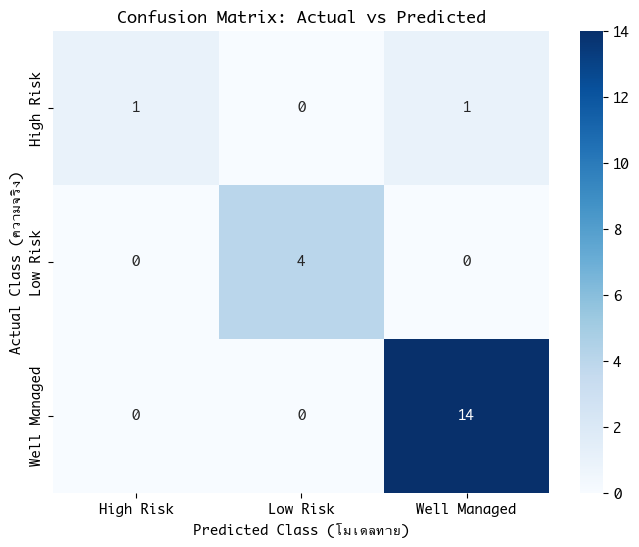

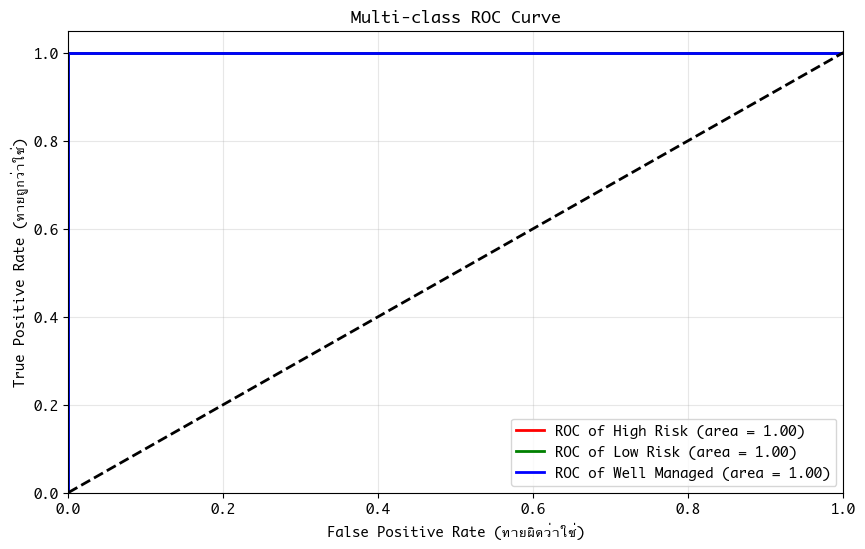

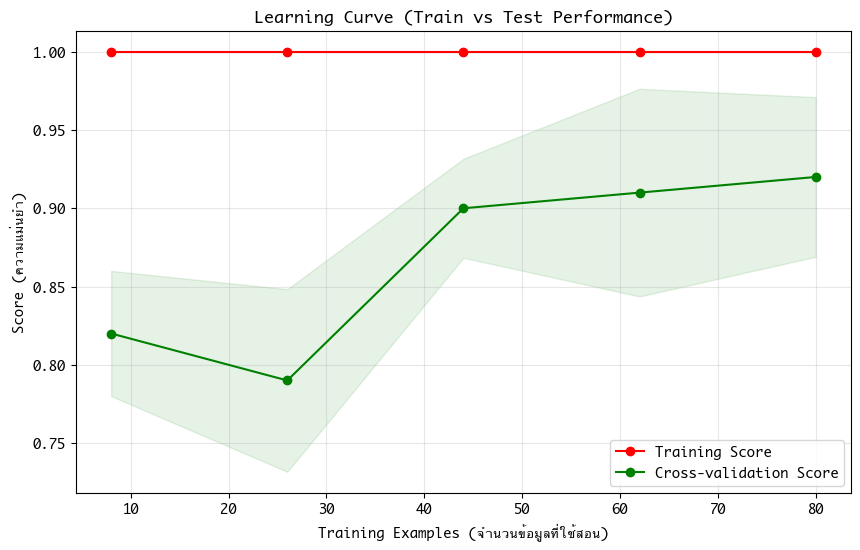

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import learning_curve
from itertools import cycle

# ==========================================
# 5. Advanced Model Evaluation (Check L3 Performance)
# ==========================================
print("🚀 Generating Advanced Evaluation Plots...")

# --- Graph 1: Confusion Matrix (ทายผิดไปลงช่องไหน?) ---
# อันนี้สำคัญสุด! จะบอกว่า "High Risk" ทายถูกกี่ตัว หรือเผลอทายผิดว่าเป็น "Safe" กี่ตัว

cm = confusion_matrix(y_test, y_pred)
labels = rf_model.classes_ # ชื่อกลุ่ม ['High Risk', 'Low Risk', 'Well Managed']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix: Actual vs Predicted')
plt.ylabel('Actual Class (ความจริง)')
plt.xlabel('Predicted Class (โมเดลทาย)')
plt.show()

# --- Graph 2: ROC Curve (กราฟเส้นโค้งวัดความเก่ง) ---
# เส้นยิ่งโก่งเข้ามุมซ้ายบนยิ่งดี (ถ้าเป็นเส้นตรงกลาง = เดามั่ว)
# เนื่องจากเรามี 3 Class เราต้องทำเส้นแยกของใครของมัน

# แปลงชื่อกลุ่มเป็นตัวเลข 0, 1, 2 เพื่อวาดกราฟ
y_test_bin = label_binarize(y_test, classes=labels)
y_score = rf_model.predict_proba(X_test) # เอาค่าความมั่นใจ (Probability) มาพล็อต
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(10, 6))
colors = cycle(['red', 'green', 'blue']) # สีประจำกลุ่ม

for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'ROC of {labels[i]} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2) # เส้นประตรงกลาง (Random Guess)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (ทายผิดว่าใช่)')
plt.ylabel('True Positive Rate (ทายถูกว่าใช่)')
plt.title('Multi-class ROC Curve')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# --- Graph 3: Learning Curve (กราฟเส้นจุดเกาะเส้นที่คุณถามหา) ---
# ดูกราฟการเรียนรู้: แกน X คือจำนวนข้อมูลที่ใช้เทรน, แกน Y คือความแม่นยำ
# ถ้าเส้น Train (สีแดง) กับ Test (สีเขียว) วิ่งเข้าหากันแล้วไปแตะที่เพดานสูงๆ = โมเดลดีมาก (ไม่ Overfit)

train_sizes, train_scores, test_scores = learning_curve(
    rf_model, X_model, y_model, cv=5, n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 5), random_state=42
)

# หาค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐาน
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.title("Learning Curve (Train vs Test Performance)")
plt.xlabel("Training Examples (จำนวนข้อมูลที่ใช้สอน)")
plt.ylabel("Score (ความแม่นยำ)")
plt.grid(True, alpha=0.3)

# Plot เส้น Train (สีแดง)
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training Score")

# Plot เส้น Test (สีเขียว)
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="g")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation Score")

plt.legend(loc="best")
plt.show()


🔧 Tuning Model to Reduce Overfitting...
Original Test Accuracy: 0.9500
Tuned Test Accuracy:    0.9500


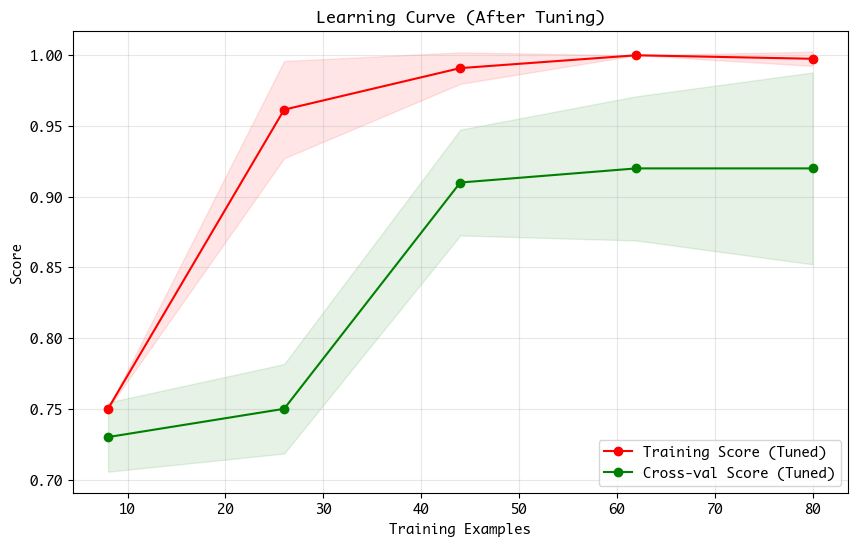

In [11]:
# ==========================================
# 6. Model Tuning (แก้ Overfitting)
# ==========================================
print("\n🔧 Tuning Model to Reduce Overfitting...")

# 1. สร้างโมเดลใหม่ที่ "จำกัดความซับซ้อน" (Pruning)
rf_model_tuned = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,            # บังคับห้ามลึกเกิน 5 ชั้น (กันจำข้อสอบ)
    min_samples_split=10,   # ต้องมีข้อมูล 10 ตัวถึงยอมให้แตกกิ่ง (เดิมคือ 2)
    max_features='sqrt',    # ใช้แค่บาง Feature ในการตัดสินใจ
    random_state=42
)

# 2. เทรนโมเดลใหม่
rf_model_tuned.fit(X_train, y_train)

# 3. เปรียบเทียบความแม่นยำ (Test Score)
old_score = rf_model.score(X_test, y_test)
new_score = rf_model_tuned.score(X_test, y_test)

print(f"Original Test Accuracy: {old_score:.4f}")
print(f"Tuned Test Accuracy:    {new_score:.4f}")

# 4. วาดกราฟ Learning Curve อันใหม่ (ดูซิว่าเส้นเขียวกับแดงชิดกันขึ้นไหม?)
train_sizes, train_scores, test_scores = learning_curve(
    rf_model_tuned, X_model, y_model, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5), random_state=42
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training Score (Tuned)")
plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-val Score (Tuned)")
plt.fill_between(train_sizes, train_mean - np.std(train_scores, axis=1), train_mean + np.std(train_scores, axis=1), alpha=0.1, color="r")
plt.fill_between(train_sizes, test_mean - np.std(test_scores, axis=1), test_mean + np.std(test_scores, axis=1), alpha=0.1, color="g")
plt.title("Learning Curve (After Tuning)")
plt.xlabel("Training Examples")
plt.ylabel("Score")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.show()

# *** ถ้าผลออกมาดี (Accuracy ไม่ตกมาก แต่กราฟชิดกัน) ให้ใช้โมเดลนี้แทน ***
# rf_model = rf_model_tuned  # ปลดคอมเมนต์บรรทัดนี้ถ้าจะเอาโมเดลจูนไปใช้ต่อใน L4

🛡️ FINAL STRESS TEST: Proving Robustness

1️⃣ Cross-Validation Test (5 Folds):
   Scores per fold: [1.   0.95 0.95 0.9  1.  ]
   ✅ Average Accuracy: 0.9600 (+/- 0.0374)
   RESULT: PASSED (Model is stable and robust across different data splits)

2️⃣ Baseline Comparison (Vs. Random Guessing):
   Dummy Model Accuracy: 0.7000
   Our Model Accuracy:   0.9500
   RESULT: PASSED (Model is significantly smarter than guessing)

3️⃣ Permutation Importance (Feature Sanity Check):


/var/folders/89/hx457xt54dl3cdz1fssyz4tr0000gn/T/ipykernel_75172/4064055057.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(perm_importance.importances[sorted_idx].T, vert=False, labels=X_test.columns[sorted_idx])


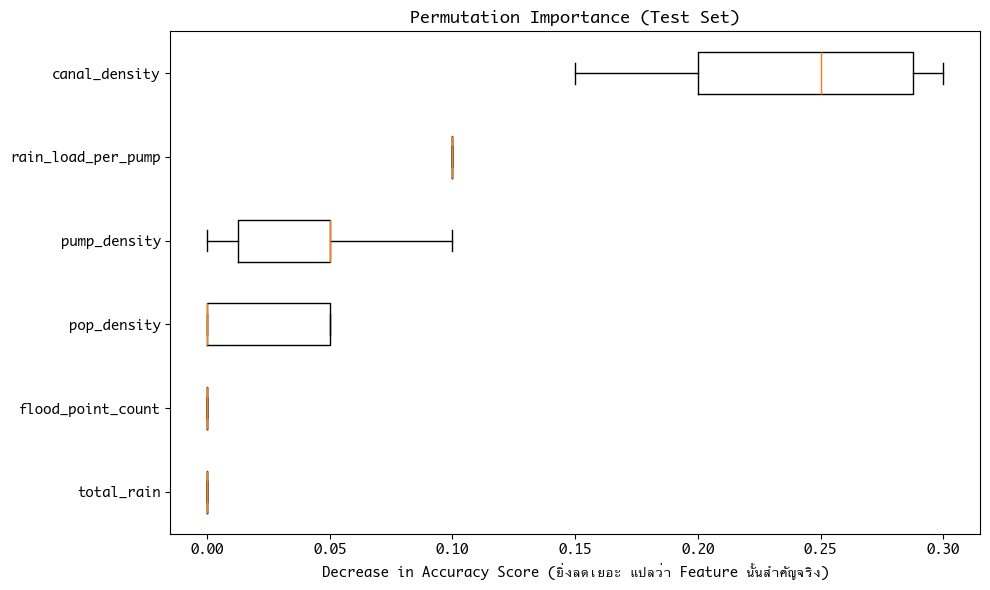

   Analysis: Check the Top Feature.
   - If 'rain_load_per_pump' causes the biggest drop -> PASSED (Logic is correct)
   - If a random feature is on top -> FAILED (Model is cheating)


In [12]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance

print(f"{'='*40}")
print("🛡️ FINAL STRESS TEST: Proving Robustness")
print(f"{'='*40}")

# ==========================================
# Test 1: k-Fold Cross-Validation (สอบ 5 สนาม)
# ==========================================
print("\n1️⃣ Cross-Validation Test (5 Folds):")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model_tuned, X_model, y_model, cv=cv, scoring='accuracy')

print(f"   Scores per fold: {cv_scores}")
print(f"   ✅ Average Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

if cv_scores.mean() > 0.90 and cv_scores.std() < 0.05:
    print("   RESULT: PASSED (Model is stable and robust across different data splits)")
else:
    print("   RESULT: WARNING (Model might be unstable)")

# ==========================================
# Test 2: Baseline Comparison (แข่งกับคนเดามั่ว)
# ==========================================
print("\n2️⃣ Baseline Comparison (Vs. Random Guessing):")
# สร้างโมเดลโง่ๆ ที่ตอบแต่ Class ที่เยอะที่สุด (Most Frequent)
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_score = dummy.score(X_test, y_test)

print(f"   Dummy Model Accuracy: {dummy_score:.4f}")
print(f"   Our Model Accuracy:   {new_score:.4f}") # new_score จากขั้นตอน Tuning

if new_score > dummy_score * 1.2: # ต้องดีกว่าอย่างน้อย 20%
    print("   RESULT: PASSED (Model is significantly smarter than guessing)")
else:
    print("   RESULT: FAILED (Model is just guessing common classes)")

# ==========================================
# Test 3: Permutation Importance (สลับขาหลอก)
# ==========================================
print("\n3️⃣ Permutation Importance (Feature Sanity Check):")
# ลองสลับข้อมูลทีละคอลัมน์แล้วดูว่า Accuracy ตกไหม
perm_importance = permutation_importance(rf_model_tuned, X_test, y_test, n_repeats=10, random_state=42)

# เรียงลำดับความสำคัญจากมากไปน้อย
sorted_idx = perm_importance.importances_mean.argsort()

plt.figure(figsize=(10, 6))
plt.boxplot(perm_importance.importances[sorted_idx].T, vert=False, labels=X_test.columns[sorted_idx])
plt.title("Permutation Importance (Test Set)")
plt.xlabel("Decrease in Accuracy Score (ยิ่งลดเยอะ แปลว่า Feature นั้นสำคัญจริง)")
plt.tight_layout()
plt.show()

print("   Analysis: Check the Top Feature.")
print("   - If 'rain_load_per_pump' causes the biggest drop -> PASSED (Logic is correct)")
print("   - If a random feature is on top -> FAILED (Model is cheating)")

⚙️ Preparing Data for Evaluation Dashboard...


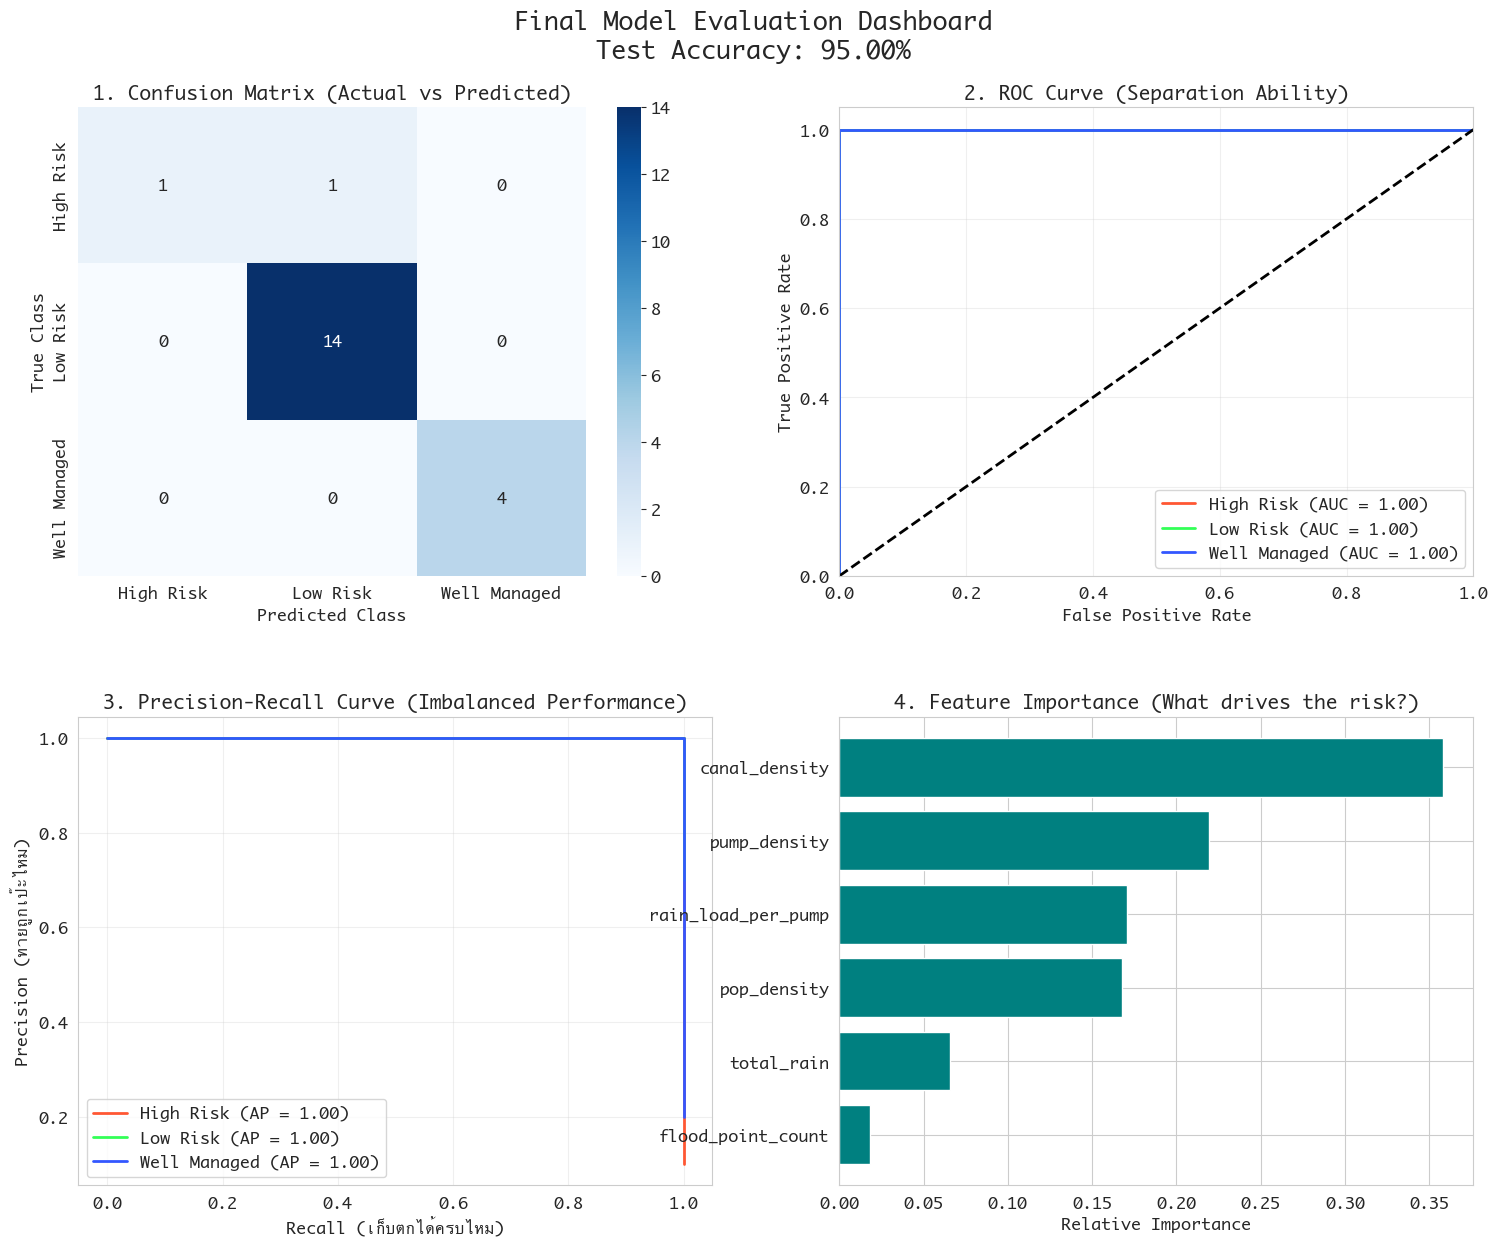

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
from itertools import cycle

# ==========================================
# 1. Prepare Data & Model (โหลดและเทรนใหม่ให้ชัวร์)
# ==========================================
print("⚙️ Preparing Data for Evaluation Dashboard...")
df = pd.read_csv('../data/PROCESSED/district_features_engineered.csv')

# Features & Target
features_cols = ['total_rain', 'rain_load_per_pump', 'pump_density', 
                 'canal_density', 'pop_density', 'flood_point_count']

# ต้องรัน K-Means เพื่อสร้าง Label ก่อน (เหมือนเดิม)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features_cols])
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Map Label (อิงตามที่คุณเช็คมาล่าสุด)
# ** เช็ค Mapping ตรงนี้อีกทีนะครับให้ตรงกับผลลัพธ์จริงของคุณ **
# 0: Low Risk, 1: High Risk, 2: Well Managed (ตัวอย่าง)
# วิธีเช็ค: ดูค่า mean ของ rain_load_per_pump
cluster_means = df.groupby('cluster')['rain_load_per_pump'].mean()
high_risk_id = cluster_means.idxmax()
low_risk_id = cluster_means.idxmin()
well_managed_id = list(set([0,1,2]) - {high_risk_id, low_risk_id})[0]

mapping = {high_risk_id: 'High Risk', low_risk_id: 'Low Risk', well_managed_id: 'Well Managed'}
df['risk_level'] = df['cluster'].map(mapping)

# Split Data
X = df[features_cols]
y = df['risk_level']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Tuned Model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_split=10, random_state=42)
rf_model.fit(X_train, y_train)

# Predict Probabilities (จำเป็นสำหรับกราฟขั้นสูง)
y_proba = rf_model.predict_proba(X_test)
classes = rf_model.classes_

# ==========================================
# 2. Plotting The Evaluation Dashboard
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
plt.subplots_adjust(hspace=0.3)

# --- Graph 1: Confusion Matrix (ความแม่นยำรายกลุ่ม) ---
y_pred = rf_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0],
            xticklabels=classes, yticklabels=classes)
axes[0,0].set_title('1. Confusion Matrix (Actual vs Predicted)', fontsize=14)
axes[0,0].set_ylabel('True Class')
axes[0,0].set_xlabel('Predicted Class')

# --- Graph 2: ROC Curve (ความเก่งในการแยกแยะ) ---
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]
colors = cycle(['#FF5733', '#33FF57', '#3357FF']) # สีส้ม, เขียว, น้ำเงิน

for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    axes[0,1].plot(fpr, tpr, color=color, lw=2,
             label=f'{classes[i]} (AUC = {roc_auc:.2f})')

axes[0,1].plot([0, 1], [0, 1], 'k--', lw=2)
axes[0,1].set_xlim([0.0, 1.0])
axes[0,1].set_ylim([0.0, 1.05])
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].set_title('2. ROC Curve (Separation Ability)', fontsize=14)
axes[0,1].legend(loc="lower right")
axes[0,1].grid(alpha=0.3)

# --- Graph 3: Precision-Recall Curve (สำหรับข้อมูล Imbalanced) ---
# กราฟนี้สำคัญมากสำหรับ High Risk (ที่มีน้อย)
for i, color in zip(range(n_classes), colors):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    avg_precision = average_precision_score(y_test_bin[:, i], y_proba[:, i])
    axes[1,0].plot(recall, precision, color=color, lw=2,
             label=f'{classes[i]} (AP = {avg_precision:.2f})')

axes[1,0].set_xlabel('Recall (เก็บตกได้ครบไหม)')
axes[1,0].set_ylabel('Precision (ทายถูกเป๊ะไหม)')
axes[1,0].set_title('3. Precision-Recall Curve (Imbalanced Performance)', fontsize=14)
axes[1,0].legend(loc="lower left")
axes[1,0].grid(alpha=0.3)

# --- Graph 4: Feature Importance (ปัจจัยที่มีผลต่อความเสี่ยง) ---
importances = rf_model.feature_importances_
indices = np.argsort(importances)
axes[1,1].barh(range(len(indices)), importances[indices], color='teal', align='center')
axes[1,1].set_yticks(range(len(indices)))
axes[1,1].set_yticklabels([features_cols[i] for i in indices])
axes[1,1].set_xlabel('Relative Importance')
axes[1,1].set_title('4. Feature Importance (What drives the risk?)', fontsize=14)

# Show
plt.suptitle(f"Final Model Evaluation Dashboard\nTest Accuracy: {rf_model.score(X_test, y_test):.2%}", fontsize=18, y=0.95)
plt.show()

In [23]:
import pandas as pd

# 1. โหลดไฟล์เดิม
df = pd.read_csv('../data/PROCESSED/district_static_clean.csv')

# 2. เปลี่ยนชื่อคอลัมน์ (Rename) ให้เป็นภาษาอังกฤษและตัวพิมพ์เล็ก (Snake Case)
# เพื่อให้ง่ายต่อการทำ Database และ API
rename_mapping = {
    'AREA': 'area',
    'num_male': 'male_pop',
    'num_female': 'female_pop',
    'num_school': 'num_schools',
    'num_hos': 'num_hospitals',
    'num_comm': 'num_communities',
    'num_temple': 'num_temples',
    'num_health': 'num_health_centers',
    'total_ready': 'pump_total_ready',
    'จำนวนจุดเสี่ยง': 'risk_points',
    'จำนวนจุดเฝ้าระวังน้ำท่วม': 'watch_points'
}

df_renamed = df.rename(columns=rename_mapping)

# 3. Save เป็นไฟล์ใหม่เตรียม Import
output_path = '../data/PROCESSED/district_static_for_db.csv'
df_renamed.to_csv(output_path, index=False)

print(f"✅ สร้างไฟล์สำหรับ Database เรียบร้อย: {output_path}")
print("Columns:", df_renamed.columns.tolist())

✅ สร้างไฟล์สำหรับ Database เรียบร้อย: ../data/PROCESSED/district_static_for_db.csv
Columns: ['dcode', 'dname', 'area', 'population', 'male_pop', 'female_pop', 'num_schools', 'num_hospitals', 'num_communities', 'num_temples', 'num_health_centers', 'canal_count', 'flood_point_count', 'floodgate_count', 'pump_number', 'pump_ready', 'pump_total_ready', 'risk_points', 'watch_points']


In [24]:
import pandas as pd

# 1. โหลดไฟล์ฝนปี 2023 และ 2024
df_2023 = pd.read_csv('../data/PROCESSED/rain/rain_with_storm_summary_2023.csv')
df_2024 = pd.read_csv('../data/PROCESSED/rain/rain_with_storm_summary_2024.csv')

# 2. รวมไฟล์ (Concatenate)
df_all = pd.concat([df_2023, df_2024], ignore_index=True)

# 3. เลือกและเปลี่ยนชื่อคอลัมน์ให้ตรงกับ Database
# เราต้องการ: date, dcode, rain_24h
df_selected = df_all[['date_object', 'dcode', 'ฝน 24 ชม.']].copy()
df_selected.columns = ['date', 'dcode', 'rain_24h']

# 4. แปลงข้อมูลให้ถูกต้อง
# แปลง rain_24h เป็นตัวเลข (ถ้ามี error ให้เป็น 0)
df_selected['rain_24h'] = pd.to_numeric(df_selected['rain_24h'], errors='coerce').fillna(0)
# แปลง date เป็น datetime
df_selected['date'] = pd.to_datetime(df_selected['date'])

# 5. Group ข้อมูล: ยุบรวมสถานีต่างๆ ในเขตเดียวกัน ให้เหลือค่าเดียวต่อวัน
# ใช้ค่าเฉลี่ย (mean) หรือค่าสูงสุด (max) ก็ได้ (แนะนำ mean สำหรับภาพรวม, max สำหรับความเสี่ยงสูงสุด)
# ในที่นี้ขอใช้ 'mean' (เฉลี่ยทั้งเขต)
df_agg = df_selected.groupby(['date', 'dcode'])['rain_24h'].mean().reset_index()

# 6. เพิ่มคอลัมน์สำหรับ Database
df_agg['is_forecast'] = False  # เพราะนี่คือฝนจริงที่ตกไปแล้ว

# 7. ตรวจสอบความเรียบร้อย
print(f"จำนวนข้อมูลทั้งหมด: {len(df_agg)} แถว")
print(df_agg.head())

# 8. Save ไฟล์เพื่อเอาไป Import เข้า Supabase
output_path = '../data/PROCESSED/rain_logs_for_db.csv'
df_agg.to_csv(output_path, index=False)
print(f"✅ สร้างไฟล์สำหรับ Import เรียบร้อย: {output_path}")

จำนวนข้อมูลทั้งหมด: 25150 แถว
        date  dcode  rain_24h  is_forecast
0 2023-01-01   1001       0.0        False
1 2023-01-01   1002       0.0        False
2 2023-01-01   1003       0.0        False
3 2023-01-01   1004       0.0        False
4 2023-01-01   1005       0.0        False
✅ สร้างไฟล์สำหรับ Import เรียบร้อย: ../data/PROCESSED/rain_logs_for_db.csv


In [26]:
import pandas as pd
import numpy as np

# 1. โหลดไฟล์
print("Loading data...")
df_2023 = pd.read_csv('../data/PROCESSED/rain/rain_with_storm_summary_2023.csv')
df_2024 = pd.read_csv('../data/PROCESSED/rain/rain_with_storm_summary_2024.csv')

# 2. รวมร่าง (Concatenate)
df_all = pd.concat([df_2023, df_2024], ignore_index=True)

# 3. แปลงข้อมูลเบื้องต้น
df_all['date'] = pd.to_datetime(df_all['date_object'])
df_all['rain_24h'] = pd.to_numeric(df_all['ฝน 24 ชม.'], errors='coerce').fillna(0)
df_all['rain_1h'] = pd.to_numeric(df_all['ฝน 1 ชม.'], errors='coerce').fillna(0)
df_all['storms'] = pd.to_numeric(df_all['active_storms_count'], errors='coerce').fillna(0)

# 4. Aggregation: ยุบรวมข้อมูลรายสถานี ให้เป็น "รายเขต-รายวัน"
# - rain_24h: ใช้ค่าเฉลี่ย (Mean) เพื่อดูภาพรวมเขต
# - rain_1h: ใช้ค่าสูงสุด (Max) เพื่อดูว่าจุดไหนตกหนักสุดในเขต (จับ Flash Flood)
# - season, storm: ใช้ค่าแรกที่เจอ (เพราะทั้งเขตเหมือนกัน)
print("Aggregating data...")

df_agg = df_all.groupby(['date', 'dcode']).agg({
    'rain_24h': 'mean',
    'rain_1h': 'max',           # ฝน 1 ชม. เอาค่า max เพื่อดูความรุนแรงสูงสุด
    'season': 'first',          # ฤดูเหมือนกันทั้งวัน
    'storms': 'max',            # จำนวนพายุ
    'active_storm_names': 'first' # ชื่อพายุ
}).reset_index()

# 5. จัดการ Format ให้ตรงกับ Database
df_agg.rename(columns={
    'rain_1h': 'max_rain_1h',
    'storms': 'storm_count',
    'active_storm_names': 'storm_names'
}, inplace=True)

# เพิ่ม flag ว่าเป็นข้อมูลจริง (History)
df_agg['is_forecast'] = False

# Handle storm names (ถ้าไม่มีให้ใส่ขีด - หรือว่าง)
df_agg['storm_names'] = df_agg['storm_names'].fillna('[]').apply(lambda x: x if x != '[]' else None)

# 6. ตรวจสอบ
print(f"Total Rows: {len(df_agg)}")
print(df_agg.head())

# 7. Export
output_path = '../data/PROCESSED/rain_logs_full_history.csv'
df_agg.to_csv(output_path, index=False)
print(f"✅ Ready to import! File saved at: {output_path}")

Loading data...
Aggregating data...
Total Rows: 25150
        date  dcode  rain_24h  max_rain_1h  season  storm_count storm_names  \
0 2023-01-01   1001       0.0          0.0  Winter            0        None   
1 2023-01-01   1002       0.0          0.0  Winter            0        None   
2 2023-01-01   1003       0.0          0.0  Winter            0        None   
3 2023-01-01   1004       0.0          0.0  Winter            0        None   
4 2023-01-01   1005       0.0          0.0  Winter            0        None   

   is_forecast  
0        False  
1        False  
2        False  
3        False  
4        False  
✅ Ready to import! File saved at: ../data/PROCESSED/rain_logs_full_history.csv


In [29]:
import pandas as pd
import geopandas as gpd
from shapely import wkt
import re

# ==========================================
# 1. ฟังก์ชันซ่อมแซม Geometry ที่ขาดหาย (The Fixer)
# ==========================================
def repair_wkt(wkt_str):
    if not isinstance(wkt_str, str): return None
    try:
        # ลองอ่านแบบปกติก่อน
        return wkt.loads(wkt_str)
    except Exception:
        # ถ้า Error แปลว่าสตริงขาด ให้ลองซ่อม
        try:
            # 1. หาจุดเริ่มต้น ((x y
            match = re.match(r"(MULTI)?POLYGON\s*\(\(([^,]+)", wkt_str)
            if not match: return None
            
            first_point = match.group(2) # เก็บพิกัดแรกไว้ปิดวง
            
            # 2. ตัดส่วนท้ายที่แหว่งๆ ทิ้ง (เอาถึงคอมม่าตัวสุดท้าย)
            last_comma_idx = wkt_str.rfind(',')
            if last_comma_idx == -1: return None
            clean_str = wkt_str[:last_comma_idx]
            
            # 3. ปิดวงเล็บให้ครบ (เติมจุดแรกเข้าไปให้เส้นบรรจบกัน)
            # สังเกตวงเล็บปิด ถ้าเป็น MULTIPOLYGON อาจต้องใช้ ))) แต่ส่วนใหญ่เขต กทม. เป็น POLYGON ))
            repaired_str = f"{clean_str}, {first_point}))"
            
            # ลองโหลดตัวที่ซ่อมแล้ว
            return wkt.loads(repaired_str)
        except:
            return None # ถ้าซ่อมไม่ไหวจริงๆ ก็ปล่อยผ่าน

# ==========================================
# 2. Main Processing Script
# ==========================================
files_to_process = [
    {'path': '../data/RAW/csv/pump_stations.csv', 'type': 'point', 'output': 'pumps_for_db.csv'},
    {'path': '../data/RAW/csv/floodgate.csv', 'type': 'point', 'output': 'floodgates_for_db.csv'},
    {'path': '../data/RAW/csv/flood_points.csv', 'type': 'point', 'output': 'floodpoints_for_db.csv'},
    # districts ใช้ฟังก์ชันซ่อมพิเศษ
    {'path': '../data/RAW/csv/districts.csv', 'type': 'polygon', 'output': 'districts_geo_for_db.csv'}
]

for file_info in files_to_process:
    print(f"🔄 Processing {file_info['path']}...")
    
    try:
        df = pd.read_csv(file_info['path'])
        
        # แปลง Geometry (ใช้ repair_wkt สำหรับทุกตัวเพื่อความชัวร์)
        df['geometry'] = df['geometry'].apply(repair_wkt)
        
        # ลบแถวที่ซ่อมไม่ได้ทิ้ง (Drop invalid)
        df = df.dropna(subset=['geometry'])
        
        # สร้าง GeoDataFrame (ระบุว่าต้นฉบับคือ UTM Zone 47N)
        gdf = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:32647")
        
        # แปลงพิกัดเป็น Lat/Long (EPSG:4326) สำหรับ Google Maps/Supabase
        gdf = gdf.to_crs(epsg=4326)
        
        # เปลี่ยนชื่อคอลัมน์ให้เป็นตัวเล็กและไม่มีช่องว่าง (Snake Case)
        gdf.columns = gdf.columns.str.lower().str.replace(' ', '_')
        
        # แปลง Geometry กลับเป็น Text (WKT) เพื่อเตรียมลง Database
        gdf['location'] = gdf['geometry'].apply(lambda x: x.wkt)
        
        # สร้าง DataFrame สุดท้าย (ตัดคอลัมน์ geometry ที่เป็น object ออก)
        df_final = pd.DataFrame(gdf.drop(columns='geometry'))
        
        # Save
        output_path = f"../data/PROCESSED/base_data/{file_info['output']}"
        df_final.to_csv(output_path, index=False)
        print(f"   ✅ Saved: {output_path} ({len(df_final)} rows)")
        
    except Exception as e:
        print(f"   ❌ Error: {e}")

print("\n✨ All conversions completed!")

🔄 Processing ../data/RAW/csv/pump_stations.csv...
   ✅ Saved: ../data/PROCESSED/base_data/pumps_for_db.csv (16 rows)
🔄 Processing ../data/RAW/csv/floodgate.csv...
   ✅ Saved: ../data/PROCESSED/base_data/floodgates_for_db.csv (77 rows)
🔄 Processing ../data/RAW/csv/flood_points.csv...
   ✅ Saved: ../data/PROCESSED/base_data/floodpoints_for_db.csv (20 rows)
🔄 Processing ../data/RAW/csv/districts.csv...
   ✅ Saved: ../data/PROCESSED/base_data/districts_geo_for_db.csv (50 rows)

✨ All conversions completed!


In [30]:
import pandas as pd
import geopandas as gpd
from shapely import wkt
import re

# ฟังก์ชันซ่อม Geometry (เหมือนเดิม)
def repair_wkt(wkt_str):
    if not isinstance(wkt_str, str): return None
    try:
        return wkt.loads(wkt_str)
    except:
        try:
            match = re.match(r"(MULTI)?POLYGON\s*\(\(([^,]+)", wkt_str)
            if not match: return None
            first_point = match.group(2)
            last_comma_idx = wkt_str.rfind(',')
            if last_comma_idx == -1: return None
            clean_str = wkt_str[:last_comma_idx]
            return wkt.loads(f"{clean_str}, {first_point}))")
        except:
            return None

# Config การแปลงไฟล์
files_config = [
    {
        'input': '../data/RAW/csv/pump_stations.csv',
        'output': 'geo_pumps_final.csv',
        'type': 'point',
        'rename': {'id_pump': 'pump_id', 'location': 'location_details'} # เปลี่ยนชื่อกันสับสน
    },
    {
        'input': '../data/RAW/csv/floodgate.csv',
        'output': 'geo_floodgates_final.csv',
        'type': 'point',
        'rename': {'id_flood': 'floodgate_id', 'location': 'location_details'}
    },
    {
        'input': '../data/RAW/csv/flood_points.csv',
        'output': 'geo_floodpoints_final.csv',
        'type': 'point',
        'rename': {'id_flood': 'floodpoint_id', 'location': 'location_name'}
    },
    {
        'input': '../data/RAW/csv/districts.csv',
        'output': 'geo_districts_border.csv',
        'type': 'polygon',
        'keep_cols': ['dcode', 'geometry'], # เก็บแค่ dcode กับ border พอ
        'rename': {} 
    }
]

for config in files_config:
    print(f"🔄 Processing {config['input']}...")
    df = pd.read_csv(config['input'])
    
    # 1. Rename Columns (เปลี่ยนชื่อให้ตรงกับ DB ที่เราจะสร้าง)
    df = df.rename(columns=config['rename'])
    
    # 2. Parse Geometry
    df['geometry'] = df['geometry'].apply(repair_wkt)
    df = df.dropna(subset=['geometry'])
    
    # 3. Convert CRS (UTM -> Lat/Long)
    gdf = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:32647")
    gdf = gdf.to_crs(epsg=4326)
    
    # 4. Create 'location' column (WKT) สำหรับ Supabase
    # (ถ้าเป็น Districts ให้ตั้งชื่อว่า border)
    geo_col_name = 'border' if config['type'] == 'polygon' else 'location'
    gdf[geo_col_name] = gdf['geometry'].apply(lambda x: x.wkt)
    
    # 5. Select Columns (ตัด Geometry เดิมทิ้ง)
    # เอาคอลัมน์ทั้งหมดที่มี (ยกเว้น geometry) + คอลัมน์ geo ใหม่
    final_cols = [c for c in gdf.columns if c != 'geometry']
    if 'keep_cols' in config: # กรณี Districts เอาแค่บางตัว
        cols_to_keep = set(config['keep_cols']) - {'geometry'} | {geo_col_name}
        final_cols = [c for c in final_cols if c in cols_to_keep]
        
    df_final = pd.DataFrame(gdf[final_cols])
    
    # Save
    output_path = f"../data/PROCESSED/base_data/{config['output']}"
    df_final.to_csv(output_path, index=False)
    print(f"   ✅ Saved: {output_path} (Columns: {list(df_final.columns)})")

🔄 Processing ../data/RAW/csv/pump_stations.csv...
   ✅ Saved: ../data/PROCESSED/base_data/geo_pumps_final.csv (Columns: ['pump_id', 'name', 'dcode', 'capacity', 'location_details', 'function', 'location'])
🔄 Processing ../data/RAW/csv/floodgate.csv...
   ✅ Saved: ../data/PROCESSED/base_data/geo_floodgates_final.csv (Columns: ['floodgate_id', 'name', 'dcode', 'location_details', 'type_gate', 'num_gate', 'size', 'location'])
🔄 Processing ../data/RAW/csv/flood_points.csv...
   ✅ Saved: ../data/PROCESSED/base_data/geo_floodpoints_final.csv (Columns: ['floodpoint_id', 'location_name', 'dcode', 'scode', 'location'])
🔄 Processing ../data/RAW/csv/districts.csv...
   ✅ Saved: ../data/PROCESSED/base_data/geo_districts_border.csv (Columns: ['dcode', 'border'])
